# 4.2 β Regularity (Appendix A.2)

Reproduces Table 4.5 and Figures 4.6-4.9 of the thesis and Tables A.5-A.11 and Figures A.6-A.9 of the
appendix (1-forms on $(0,\pi)^2$: the $L^\infty\setminus W^{1,\infty}$ shears $\beta_6$, $\beta_7$,
$\beta_8$ and the $L^q$ fields $\beta_9(\alpha)$, $\beta_{11}$). Imports the shared modules
`spectral_common.py` and `pseudospectra_partial_schur.py` from this folder; Table A.9 also needs the `gmsh`
Python package. Run top to bottom in a kernel with Firedrake, SLEPc and MUMPS; figures are written to
`./figures` (`.eps` and `.pdf`).


## Setup


Plot style, imports and the panel helpers (`conv_panel`, `ps_grid`).


In [3]:
import matplotlib.pyplot as plt

# 1. Document parameters
latex_textwidth_pt = 426.79135   # \the\textwidth of the dissertation
inches_per_pt = 1.0 / 72.27
fig_width = latex_textwidth_pt * inches_per_pt
fig_height = fig_width * 0.75
base_fontsize = 11

# 2. Update rcParams globally
plt.rcParams.update({
    "figure.figsize": (fig_width, fig_height),

    # Match LaTeX fonts
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],

    # Match font sizes exactly
    "font.size": base_fontsize,
    "axes.titlesize": base_fontsize,
    "axes.labelsize": base_fontsize,
    "legend.fontsize": base_fontsize - 1,
    "xtick.labelsize": base_fontsize - 2,
    "ytick.labelsize": base_fontsize - 2,

    # Refine line weights for a professional look
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "grid.linewidth": 0.5,
})

#: The pseudospectrum panels are drawn smaller and denser, so that a grid of six
#: still reads at text width.
PS_RC = {
    "figure.figsize": (fig_width, fig_height),
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": base_fontsize,
    "axes.titlesize": base_fontsize - 3,
    "axes.labelsize": base_fontsize - 4,
    "legend.fontsize": base_fontsize - 4,
    "xtick.labelsize": base_fontsize - 4,
    "ytick.labelsize": base_fontsize - 4,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "grid.linewidth": 0.5,
    "lines.markersize": 0.5,
}

In [4]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Optional

import numpy as np
import pandas as pd
import scipy.sparse.linalg as spla
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from firedrake import *
from firedrake.function import PointEvaluator
from firedrake.pyplot import triplot, tripcolor

from petsc4py import PETSc
from slepc4py import SLEPc

import spectral_common as sc
import pseudospectra_partial_schur as ps
from spectral_common import (crisscross_mesh, solve_pencil, border_gauge,
                             condition_estimates, rates, assign,
                             agreeing_digits, spread, L_DOMAIN, KAPPA_LOG)

# `from firedrake import *` exports a `logging` of its own, so the standard
# library one has to be re-imported under another name afterwards.
import logging as stdlogging
stdlogging.getLogger("firedrake").setLevel(stdlogging.ERROR)
stdlogging.getLogger("tsfc").setLevel(stdlogging.ERROR)

FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)

# Everything the LaTeX block above does not set: fonts and sizes come from there.
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight",
                     "savefig.pad_inches": 0.02})


def show(df, caption=None, **kw):
    """`sc.fmt_table` wired to this notebook's display function."""
    return sc.fmt_table(df, caption=caption,
                        display_fn=lambda c: display(Markdown(f"**{c}**")), **kw)


print(f"PETSc scalars: {PETSc.ScalarType.__name__}")

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


PETSc scalars: float64


In [5]:
from matplotlib.ticker import LogLocator, NullFormatter

#: The colourblind-safe palette and marker cycle used by every panel here and in
#: `baseline.ipynb`, one entry per tracked eigenvalue.
EIG_COLOURS = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00"]
EIG_MARKS = ["o", "s", "^", "v", "d"]

#: Figure labels for the fields, named as in Table 4.1 of the dissertation.
BETA_TEX = {"b6": r"$\beta_6$", "b7": r"$\beta_7$", "b8": r"$\beta_8$",
            "b9": r"$\beta_9$"}

half_width = fig_width * 0.49          # two panels side by side across the text
half_height = half_width * 1.05
sub_fontsize = base_fontsize - 1

#: The y-label every convergence panel in the dissertation carries.
REL_ERR = r"$|\lambda_h^{(i)} - \lambda_{ref}^{(i)}| / \lambda_{ref}^{(i)}$"


def save_fig(fig, name):
    r"""Write one panel to `figures/<name>.eps` and `.pdf`.

    Both, because a LaTeX `\includegraphics` given no extension prefers the
    `.pdf`, and a stale one from an earlier style would then be picked silently.
    """
    for ext in ("eps", "pdf"):
        fig.savefig(FIGDIR / f"{name}.{ext}")


def conv_panel(x, series, *, xlabel, ylabel, title, name, refs=(), logx=True,
               legend_loc="lower right", ncol=2, xticks=None, numticks=12,
               minor_x=None, xmax_at_least=None):
    r"""One convergence panel in the dissertation's style.

    `series` is a list of `(label, y)`; `refs` a list of `(x, y, kwargs)` for the
    reference slopes, drawn black unless the kwargs say otherwise. The bottom of
    the axis is stretched by a decade so the legend has somewhere to sit.
    """
    minor_x = logx if minor_x is None else minor_x
    fig, ax = plt.subplots(figsize=(half_width, half_height))
    plot = ax.loglog if logx else ax.semilogy

    for j, (label, y) in enumerate(series):
        plot(x, y, marker=EIG_MARKS[j % len(EIG_MARKS)],
             color=EIG_COLOURS[j % len(EIG_COLOURS)], ms=4.0, lw=1.0, label=label)
    for xr, yr, kw in refs:
        plot(xr, yr, **{"color": "k", "lw": 1.0, **kw})

    ax.set_xlabel(xlabel, fontsize=sub_fontsize)
    ax.set_ylabel(ylabel, fontsize=sub_fontsize)
    ax.set_title(title, fontsize=sub_fontsize)
    ax.grid(True, which="major", color="gray", linestyle="-", alpha=0.5, lw=0.5)
    ax.grid(True, which="minor", color="gray", linestyle=":", alpha=0.3, lw=0.5)

    if xticks is not None:
        ax.set_xticks(list(xticks))

    locmin = LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=numticks)
    if minor_x:
        ax.xaxis.set_minor_locator(locmin)
        ax.xaxis.set_minor_formatter(NullFormatter())
    ax.yaxis.set_minor_locator(locmin)
    ax.yaxis.set_minor_formatter(NullFormatter())

    ax.set_ylim(bottom=ax.get_ylim()[0] * 0.1)
    if xmax_at_least is not None:
        ax.set_xlim(right=max(ax.get_xlim()[1], xmax_at_least))
    ax.legend(fontsize=sub_fontsize - 2, frameon=True, edgecolor="lightgray",
              ncol=ncol, loc=legend_loc, handlelength=1.5, borderpad=0.4)
    plt.tight_layout(pad=0.3)
    save_fig(fig, name)
    plt.show()


def ps_grid(panels, titles, name, *, scale=None, row_height=0.33,
            labels="panel", cbar_fraction=0.045):
    r"""A grid of pseudospectrum panels across the text width.

    `panels` is a list of rows, each row a list of results, and `titles` matches
    it.  `scale` is the common `(vmin, vmax)` for every panel -- pass the one
    `ps.shared_scale` returned for the whole group, which it only permits when
    every panel is drawn on the same window.  The colour bar sits at the end of
    each row; `labels="panel"` letters every panel (a), (b), ... row by row and
    `labels="row"` letters the rows only, as Figure 4.7 does.
    """
    nrow, ncol = len(panels), len(panels[0])
    with matplotlib.rc_context(PS_RC):
        fig, axes = plt.subplots(nrow, ncol,
                                 figsize=(fig_width, fig_width * row_height * nrow),
                                 sharex=True, sharey=True, squeeze=False)
        k = 0
        for i, row in enumerate(panels):
            for j, res in enumerate(row):
                ax, last = axes[i][j], (j == ncol - 1)
                ps.plot_pseudospectrum(
                    res, ax=ax, cmap="magma", title=titles[i][j],
                    vmin=None if scale is None else scale[0],
                    vmax=None if scale is None else scale[1],
                    per_decade=2, grid=True, legend=(i == 0 and j == 0),
                    colorbar=last,
                    colorbar_label=r"$\sigma_{\min}(z - L)$" if last else None,
                    colorbar_kw={"pad": 0.02, "fraction": cbar_fraction} if last else None,
                    legend_kw={"frameon": True, "facecolor": "lightgray",
                               "edgecolor": "black", "loc": "lower left",
                               "fontsize": base_fontsize - 1},
                    eig_kw={"color": "white", "markersize": 3})
                if labels == "panel" or (labels == "row" and j == 0):
                    ax.text(-0.05, 1.05, f"({chr(97 + k)})", transform=ax.transAxes,
                            fontsize=base_fontsize, fontweight="bold", va="bottom")
                    k += 1
                if j:
                    ax.set_ylabel("")
                if i < nrow - 1:
                    ax.set_xlabel("")
        if axes[0][0].get_legend():
            for text in axes[0][0].get_legend().get_texts():
                text.set_text(r"$\lambda_i$")
        plt.tight_layout(pad=0.2)
        save_fig(fig, name)
        plt.show()

Formulations, `build_pencil`, the shift-and-invert solve (`solve_form`) and the velocity fields.


In [13]:
def cross2d(a, b):
    r"""Scalar 2D cross product $(a\times b)_z = a_1b_2 - a_2b_1$.

    Antisymmetric, so the ordering is load-bearing: the induction term needs
    $u\times\beta$, the proxy of the contraction $\iota^1_\beta u$.
    """
    return a[0] * b[1] - a[1] * b[0]


def space(form, mesh, r):
    """The mixed (or scalar) space of one formulation at polynomial degree r."""
    if form == "A(P)":
        return FunctionSpace(mesh, "CG", r)
    if form == "B(N1)":
        return FunctionSpace(mesh, "N1curl", r) * FunctionSpace(mesh, "CG", r)
    return FunctionSpace(mesh, "N2curl", r) * FunctionSpace(mesh, "CG", r + 1)


def build_pencil(form, mesh, r=1, beta=None, eps=Constant(1.0)):
    r"""Assemble $(A, M)$ for one formulation.  $M$ is singular in every case."""
    if form == "A(P)":
        V = space(form, mesh, r)
        a_, z = TrialFunction(V), TestFunction(V)
        a = eps * inner(grad(a_), grad(z)) * dx
        if beta is not None:
            a += inner(dot(beta, grad(a_)), z) * dx
        K, M = assemble(a).petscmat, assemble(inner(a_, z) * dx).petscmat
        # g_i = \int phi_i : the gauge (A, s) = 0 as a rank-one border.
        g = np.asarray(assemble(TestFunction(V) * dx).dat.data_ro).copy()
        A_b, M_b = border_gauge(K, M, g)
        return A_b, M_b, V

    W = space(form, mesh, r)
    (u, q) = TrialFunctions(W)
    (v, s) = TestFunctions(W)
    a = eps * inner(curl(u), curl(v)) * dx
    if beta is not None:
        a += inner(cross2d(u, beta), curl(v)) * dx
    a += (-inner(grad(q), v) + inner(u, grad(s))) * dx
    # On an H(curl) space a DirichletBC constrains the TANGENTIAL trace, which is
    # the perfectly-conducting condition; p = 0 puts the multiplier in H^1_0.
    bcs = [DirichletBC(W.sub(0), Constant((0.0, 0.0)), "on_boundary"),
           DirichletBC(W.sub(1), Constant(0.0), "on_boundary")]
    # weight=0.0 gives the constrained rows a zero mass diagonal, so the boundary
    # modes go to infinity rather than to a spurious lambda = 1.
    return (assemble(a, bcs=bcs).petscmat,
            assemble(inner(u, v) * dx, bcs=bcs, weight=0.0).petscmat, W)


FORMS = ["B(N1)", "B(N2)", "A(P)"]
TEX = {"B(N1)": r"$B(\mathcal{N}^{\mathrm{I}}_r)$",
       "B(N2)": r"$B(\mathcal{N}^{\mathrm{II}}_r)$",
       "A(P)":  r"$A(\mathcal{P}_r)$"}
TAG = {"B(N1)": "BN1", "B(N2)": "BN2", "A(P)": "AP"}
TEX1 = {f: t.replace("_r", "_1") for f, t in TEX.items()}
TEXP = {f: t.replace("_r", "_p") for f, t in TEX.items()}
STYLE = {"B(N1)": "C0", "B(N2)": "C1", "A(P)": "C2"}


def solve_form(form, mesh, r=1, beta=None, Rm=1.0, tau=None, nev=25, n_eigs=None,
               **meta):
    r"""Assemble and solve one configuration.  ``tau`` defaults to $0.9\varepsilon$."""
    A, M, W = build_pencil(form, mesh, r, beta=beta, eps=Constant(1.0 / Rm))
    return solve_pencil(A, M, (0.9 / Rm) if tau is None else tau, nev=nev,
                        n_eigs=n_eigs, space=W, form=form, r=r, Rm=Rm, **meta)


def eigenfunction(res, k):
    """The k-th eigenmode: the H(curl) field, or the potential for A(P)."""
    vr, vi = res.A.createVecRight(), res.A.createVecRight()
    res.solver.getEigenvector(int(res.index[k]), vr, vi)
    arr = np.asarray(vr.getArray())
    if res.meta["form"] == "A(P)":
        f = Function(res.space)
        f.dat.data[:] = arr[:res.space.dim()]
        return f
    f = Function(res.space)
    with f.dat.vec_wo as fv:
        fv.setArray(arr[:fv.getLocalSize()])
    return f.subfunctions[0]

In [6]:
@dataclass(frozen=True)
class Field:
    """A named velocity field together with the properties that matter here."""
    key: str
    tex: str
    regularity: str
    gradient: bool          # beta = grad(phi)?  -> real spectrum (King)
    solenoidal: bool
    sup: Optional[float]    # ||beta||_Linf, or None when unbounded
    _build: Callable

    def __call__(self, mesh, L=L_DOMAIN, **kw):
        return self._build(mesh, L, **kw)


def _b6(mesh, L):
    x, y = SpatialCoordinate(mesh)
    return as_vector([conditional(gt(x, Constant(L / 2)), 1.0, -1.0), Constant(0.0)])


def _b7(mesh, L):
    x, y = SpatialCoordinate(mesh)
    return as_vector([conditional(gt(y, Constant(L / 2)), 1.0, -1.0), Constant(0.0)])


def _b8(mesh, L):
    x, y = SpatialCoordinate(mesh)
    s = conditional(gt(x, Constant(L / 2)), 1.0, -1.0)
    return as_vector([s, s])


def _b9(mesh, L, alpha=1.5, delta=1e-12):
    r"""The $L^p$ vortex.  ``delta`` floors $r_c$ so that the expression stays
    finite if a quadrature point lands on the centre; it is far below the
    distance from the centre to the nearest quadrature point on any mesh used
    here, so it changes nothing that is measured."""
    x, y = SpatialCoordinate(mesh)
    xc = yc = Constant(L / 2)
    r = sqrt((x - xc) ** 2 + (y - yc) ** 2 + Constant(delta))
    return as_vector([-(y - yc) / r ** alpha, (x - xc) / r ** alpha])


FIELDS = {
    "b6": Field("b6", r"$(\mathrm{sign}(x-\frac{\pi}{2}),\,0)$",
                r"$L^\infty\setminus W^{1,\infty}$", True, False, 1.0, _b6),
    "b7": Field("b7", r"$(\mathrm{sign}(y-\frac{\pi}{2}),\,0)$",
                r"$L^\infty\setminus W^{1,\infty}$", False, True, 1.0, _b7),
    "b8": Field("b8", r"$(\mathrm{sign}(x-\frac{\pi}{2}),\,\mathrm{sign}(x-\frac{\pi}{2}))$",
                r"$L^\infty\setminus W^{1,\infty}$", False, False, np.sqrt(2.0), _b8),
    "b9": Field("b9", r"$(-\hat y/r^{\alpha},\ \hat x/r^{\alpha})$",
                r"$L^p$", False, True, None, _b9),
}
ROUGH = ["b6", "b7", "b8"]          # the L^inf \ W^{1,inf} family
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

Reference spectra for $\beta_6$, $\beta_7$, $\beta_8$ at $R_m = 1$ (criss-cross $N = 64$, $p = 3$, $\tau = 0.9$, 200 eigenvalues, first ten matched; the mean of the three formulations is kept as `REFERENCE` for the $h$/$p$ studies). The second cell tabulates them: this pair is Table A.11.


In [6]:
N_REF, R_REF, NEV_REF = 64, 3, 200
N_show = 10          # matched against, even though only the first five are shown
RM_ref = 1

mesh_ref = crisscross_mesh(N_REF)
ref_runs, REFERENCE = {}, {}
for key in ROUGH:
    beta_ref = FIELDS[key](mesh_ref)
    for form in FORMS:
        ref_runs[(key, form)] = solve_form(form, mesh_ref, R_REF, beta=beta_ref, Rm = RM_ref,
                                           nev=NEV_REF, n_eigs=N_show, field=key)
    stack = np.array([ref_runs[(key, f)].values[:N_show] for f in FORMS])
    # The reference is the mean of the three: they agree to far better than the
    # discretisation error of anything measured against it.
    REFERENCE[key] = stack.mean(axis=0)

TEX3 = {"B(N1)": r"$B(\mathcal{N}_3^{\mathrm{I}})$",
        "B(N2)": r"$B(\mathcal{N}_3^{\mathrm{II}})$",
        "A(P)": r"$A(\mathcal{P}_3)$"}

In [7]:

rows = []
for key in ROUGH:
    stack = np.array([ref_runs[(key, f)].values[:N_show] for f in FORMS])
    sprd = spread(stack)
    for j in range(N_show):
        rows.append(dict(field=BETA_TEX[key], mode=str(j + 1),
                         **{TEX3[f]: stack[i, j] for i, f in enumerate(FORMS)},
                         **{"Spread": sprd[j],
                            "Digits": agreeing_digits(stack[:, j])}))
    # The conditioning of the shifted pencil, as its own row under each field.
    kap = {f: ref_runs[(key, f)].kappa.get("MUMPS COND1", np.nan) for f in FORMS}
    rows.append(dict(field=BETA_TEX[key], mode=r"$\kappa(A-\tau M)$",
                     **{TEX3[f]: f"{kap[f]:.2e}" if pd.notna(kap[f]) else "--"
                        for f in FORMS},
                     **{"Spread": np.nan, "Digits": np.nan}))

df_cv = pd.DataFrame(rows).set_index(["field", "mode"])
show(df_cv, default="{:.9f}", rules=[("Spread", "{:.2e}"), ("Digits", "{:.0f}")],
     caption=rf"Comparison of the first five eigenvalues, spread and matching digits "
             rf"across the three discretisations for $\beta_6$, $\beta_7$ and "
             rf"$\beta_8$, at $R_m = 1$ on a uniform criss-cross grid "
             rf"($N = {N_REF}$) with $p = {R_REF}$. The MUMPS condition number "
             rf"$\kappa(A-\tau M)$ of the shifted pencil is given for each "
             rf"configuration, $\tau = 0.9$.")

**Comparison of the first five eigenvalues, spread and matching digits across the three discretisations for $\beta_6$, $\beta_7$ and $\beta_8$, at $R_m = 1$ on a uniform criss-cross grid ($N = 64$) with $p = 3$. The MUMPS condition number $\kappa(A-\tau M)$ of the shifted pencil is given for each configuration, $\tau = 0.9$.**

$B(\mathcal{N}_3^{\mathrm{I}})$  \
field     mode                                                 
$\beta_6$ 1                                      1.000000000   
          2                                      1.796048353   
          3                                      2.796048353   
          4                                      4.000000000   
          5                                      4.250000000   
          6                                      5.250000000   
          7                                      5.796048353   
          8                                      8.250000000   
          9                                      9.000000000   
          10                                     9.870837389   
          $\kappa(A-\tau M)$                        2.47e+05   
$\beta_7$ 1                                      1.000000000   
          2                                      1.157958444   
          3                                      2.336746809   
          4                                      4.000000000   
          5                                      4.058368874   
          6                                 5.23761+0.36037i   
          7                                 5.23761-0.36037i   
          8                                      8.733519112   
          9                                      9.000000000   
          10                                     9.127702295   
          $\kappa(A-\tau M)$                        2.86e+05   
$\beta_8$ 1                                      1.113944642   
          2                                      1.796048353   
          3                                      3.408176527   
          4                                      3.732118686   
          5                                      4.250000000   
          6                                 5.80949+0.18708i   
          7                                 5.80949-0.18708i   
          8                                      8.825199909   
          9                                      9.030133394   
          10                                     9.870837389   
          $\kappa(A-\tau M)$                        2.49e+05   

                             $B(\mathcal{N}_3^{\mathrm{II}})$  \
field     mode                                                  
$\beta_6$ 1                                       1.000000000   
          2                                       1.796048353   
          3                                       2.796048353   
          4                                       4.000000000   
          5                                       4.250000000   
          6                                       5.250000000   
          7                                       5.796048353   
          8                                       8.250000000   
          9                                       9.000000000   
          10                                      9.870837389   
          $\kappa(A-\tau M)$                         2.46e+05   
$\beta_7$ 1                                       1.000000000   
          2                                       1.157958445   
          3                                       2.336746809   
          4                                       4.000000000   
          5                                       4.058368875   
          6                                  5.23761+0.36037i   
          7                                  5.23761-0.36037i   
          8                                       8.733519113   
          9                                       9.000000000   
          10                                      9.127702297   
          $\kappa(A-\tau M)$                         2.84e+05   
$\beta_8$ 1                                       1.113944642   
          2                                       1.796048353   
          3                                       3.408176526   
          4                      

Pseudospectrum constants (`PS_N = 64`, `PS_R = 3`, `PS_NEV = 200`, windows, `mesh_ps`) and the driver `run_ps`. The constants cell must run before `run_ps` is defined, because its default arguments bind `PS_WINDOW`, `PS_NEV` and `PS_R` at definition time.


In [11]:
PS_N, PS_R, PS_NEV = 64,3, 200
PS_WINDOW = ((0.0, 22.0), (-5.0, 5.0))

mesh_ps = crisscross_mesh(PS_N)

PS_WINDOW_B7 = ((0.0, 12.0), (-4.0, 4.0))
# Cell Peclet: ||beta_8|| = sqrt(2), so N >~ pi*sqrt(2)*Rm/2 keeps the
# unstabilised discretisation honest.  N = 20 supports Rm up to about 9.
for Rm in (1.0, 10, 20):
    print(f"Rm = {Rm:4.1f}   cell Peclet = "
          f"{(np.pi / PS_N) * FIELDS['b7'].sup * Rm / 2:.2f}")

Rm =  1.0   cell Peclet = 0.02
Rm = 10.0   cell Peclet = 0.25
Rm = 20.0   cell Peclet = 0.49


In [10]:
def metric_for(form, mesh, r=PS_R):
    r"""The Gram matrix of the norm a perturbation is measured in.

    `None` asks the module for the pencil's own M, which for the two B rows is
    already the $L^2$ metric on the field.  A(P) gets the stiffness matrix
    instead, so that what is measured is $|A|_{H^1} = \|\nabla\times A\|_{L^2} =
    \|B\|_{L^2}$.  The rank-one gauge border needs no padding: a metric that is a
    leading block of the pencil is accepted, and the border carries no physical
    norm.
    """
    if form != "A(P)":
        return None
    V = space(form, mesh, r)
    a_, z = TrialFunction(V), TestFunction(V)
    return assemble(inner(grad(a_), grad(z)) * dx).petscmat


def run_ps(form, field_key, Rm=1.0, alpha=None, window=PS_WINDOW, nev=PS_NEV,
           mesh=None, r=PS_R, tau=None):
    """Assemble one pencil and hand it to the pseudospectrum engine."""
    mesh = mesh_ps if mesh is None else mesh
    tau = (0.9 / Rm) if tau is None else tau
    beta = (FIELDS[field_key](mesh) if alpha is None
            else FIELDS[field_key](mesh, alpha=alpha))
    A, M, W = build_pencil(form, mesh, r, beta=beta, eps=Constant(1.0 / Rm))
    kappa = condition_estimates(A, M, tau)
    # NB: `field` is already a key of the result dict (the sigma_min grid), so
    # the metadata key for which velocity field this is must be named otherwise.
    out = ps.pseudospectrum(A, M, tau, nev=nev, window=window,
                            metric=metric_for(form, mesh, r),
                            form=form, beta=field_key, Rm=Rm, alpha=alpha,
                            label=FIELDS[field_key].tex)
    out["kappa1"] = kappa[r"Hager $\kappa_1$"]
    return out

## Table 4.5: Exact eigenvalues for β6, β7, β8 at Rm = 1


Analytical eigenvalues of $\beta_6$, $\beta_7$, $\beta_8$ at $R_m = 1$, first ten modes; the transcendental roots by Brent's method at tolerance $10^{-15}$. `compute_exact_spectra` is also the exact reference for $\beta_6$ in the $h$/$p$ studies below.


In [12]:
import numpy as np
from scipy.optimize import root_scalar
import pandas as pd

def compute_exact_spectra(Rm=1.0, num_modes=5, xtol=1e-14, rtol=1e-14, maxiter=100):
    eps = 1.0 / Rm
    
    k_roots = []
    for j in range(10):  
        left_bracket = 2 * j + 1 + 1e-9  
        right_bracket = 2 * j + 2        
        
        # Pass tolerances directly into root_scalar
        res = root_scalar(
            lambda k: np.tan(k * np.pi / 2) + 2 * eps * k, 
            bracket=[left_bracket, right_bracket], 
            method='brentq',
            xtol=xtol,       # Absolute tolerance for the root
            rtol=rtol,       # Relative tolerance for the root
            maxiter=maxiter  # Maximum number of iterations
        )
        
        # Optional: Raise an error if the algorithm failed to converge
        if not res.converged:
            raise ValueError(f"Root finder failed to converge for mode {j}: {res.flag}")
            
        k_roots.append(res.root)
        
    # 2. Generate candidate eigenvalues for beta_6
    b6_set1 = [eps * n**2 for n in range(1, 20)]
    b6_set2 = [eps * (4 * m**2 + n**2) + 1 / (4 * eps) for n in range(10) for m in range(1, 10)]
    b6_set3 = [eps * (k**2 + n**2) + 1 / (4 * eps) for n in range(10) for k in k_roots]
    
    b6_spectrum = sorted(b6_set1 + b6_set2 + b6_set3)[:num_modes]
    
    # 3. Generate candidate eigenvalues for beta_7
    b7_spectrum = sorted([eps * n**2 for n in range(1, num_modes + 1)])
    
    # 4. Generate candidate eigenvalues for beta_8 
    b8_set1 = [4 * eps * m**2 + 1 / (4 * eps) for m in range(1, 10)]
    b8_set2 = [eps * k**2 + 1 / (4 * eps) for k in k_roots]
    
    b8_spectrum = sorted(b8_set1 + b8_set2)[:num_modes]
    
    # 5. Tabulate the results
    df = pd.DataFrame({
        'Index': range(1, num_modes + 1),
        'beta_6': b6_spectrum,
        'beta_7': b7_spectrum,
        'beta_8': b8_spectrum
    })
    
    return df

# Force pandas to display 14 decimal places to match our tight tolerance
pd.set_option('display.precision', 14)

# Execute with custom precision
exact_table = compute_exact_spectra(Rm=1.0, num_modes=10, xtol=1e-15, rtol=1e-15)
print(exact_table.to_string(index=False))

 Index           beta_6  beta_7             beta_8
     1 1.00000000000000     1.0   1.79604835284238
     2 1.79604835284238     4.0   4.25000000000000
     3 2.79604835284238     9.0   9.87083738901106
     4 4.00000000000000    16.0  16.25000000000000
     5 4.25000000000000    25.0  25.88063433590210
     6 5.25000000000000    36.0  36.25000000000000
     7 5.79604835284238    49.0  49.88351956600346
     8 8.25000000000000    64.0  64.25000000000000
     9 9.00000000000000    81.0  81.88473247286746
    10 9.87083738901106   100.0 100.25000000000000


## Figure 4.6: A(P_p) convergence under β6


$h$-refinement ($p = 1$, $N \in \{4,8,16,32\}$ by `MeshHierarchy`) and $p$-refinement ($N = 6$, $p = 1,\dots,4$) of the first five eigenvalues for all three formulations and all three shears; $R_m = 1$, $\tau = 0.9$, 25 eigenvalues, $\beta_6$ against the exact spectrum, $\beta_7$/$\beta_8$ against `REFERENCE`. Writes `breg1_h_{b6,b7,b8}_{AP,BN1,BN2}` and `breg1_p_{b6,b7,b8}_{AP,BN1,BN2}`; the thesis figure is `breg1_h_b6_AP.eps` + `breg1_p_b6_AP.eps`, the full grids are Figures A.6/A.7. The three `h_tables` cells each rebind the dictionary; the rate-summary cell that follows them refills the missing (formulation, field) entries before the panel cell reads all nine.


In [27]:
H_LEVELS = (4, 8, 16, 32)
EIG_COLOURS = ["C0", "C1", "C2", "C3", "C4"]
EIG_COLS = [rf"$\lambda_{{{j+1}}}$" for j in range(5)]
REFERENCE_LP = {}          # filled in Section 4

def reference_for(field_key, alpha):
    return REFERENCE[field_key] if alpha is None else REFERENCE_LP[(field_key, alpha)]

def h_study(form, field_key, levels=H_LEVELS, r=1, Rm=1, alpha=None, structure=True):
    """Errors of the first five eigenvalues against the reference, level by level."""
    
    # 1. Conditionally load exact spectra for b6, otherwise use the numerical reference
    if field_key == "b6":
        # Compute exact eigenvalues dynamically for the given Rm
        exact_df = compute_exact_spectra(Rm=Rm, num_modes=5, xtol=1e-15, rtol=1e-15)
        ref = exact_df['beta_6'].values
    else:
        ref = reference_for(field_key, alpha)
        
    rows = []
    if not structure:
        base_coarse = unstructured_square_mesh(N=H_LEVELS[0])
    else:
        base_coarse = crisscross_mesh(N=H_LEVELS[0])

    hierarchy = MeshHierarchy(base_coarse, refinement_levels=len(H_LEVELS)-1)

    # level_idx: 0, 1, 2, 3.   N_val: 4, 8, 16, 32.
    for level_idx, N_val in enumerate(levels):
        # Access the sequentially indexed mesh from the hierarchy
        mesh = hierarchy[level_idx]
        
        beta = (FIELDS[field_key](mesh) if alpha is None 
                else FIELDS[field_key](mesh, alpha=alpha))
        res = solve_form(form, mesh, r, beta=beta, Rm=Rm, nev=25, field=field_key)
        
        # Matched by value, not by position, so that an inserted or missing mode
        # cannot masquerade as a loss of convergence.
        got = assign(ref, res.values)
        
        # Calculate h using the physical dimension N_val
        rows.append(dict(N=N_val, h=np.pi / N_val, dof=res.size,
                         **{EIG_COLS[j]: abs(got[j] - ref[j]) / abs(ref[j]) 
                            for j in range(5)},
                         # Replaced res.kappa1 with the exact MUMPS COND1 dictionary fetch
                         **{r"$\kappa_1$": res.kappa.get("MUMPS COND1", np.nan)}))
                            
    return pd.DataFrame(rows).set_index("N")

def rate_frame(df, cols):
    """Interleave each error column with its observed order."""
    out = pd.DataFrame(index=df.index)
    out["h"] = df["h"]
    for c in cols:
        out[c] = df[c]
        out[f"rate {c}"] = rates(df["h"], df[c])
    out[r"$\kappa_1$"] = df[r"$\kappa_1$"]
    return out

In [28]:
h_tables = {(f, "b6"): h_study(f, "b6", r=1, Rm=1, alpha=None, structure = True) for f in FORMS}
for f in FORMS:
    display(show(rate_frame(h_tables[(f, "b6")], EIG_COLS), default="{:.3e}",
                 rules=[("rate", "{:.2f}"), ("h", "{:.5f}"), (r"$\kappa_1$", "{:.2e}")],
                 caption=rf"$h$-refinement, **{f}**, field `b6`, $r = 1$, $R_m = 1$"))

**$h$-refinement, **B(N1)**, field `b6`, $r = 1$, $R_m = 1$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
4,0.78540,4.618e-03,--,4.934e-04,--,1.929e-02,--,5.250e-03,--,3.047e-03,--,6.32e+02
8,0.39270,1.060e-03,2.12,1.608e-04,1.62,4.735e-03,2.03,2.069e-03,1.34,1.008e-03,1.60,2.09e+03
16,0.19635,2.594e-04,2.03,4.280e-05,1.91,1.179e-03,2.01,5.547e-04,1.90,2.615e-04,1.95,4.10e+03
32,0.09817,6.450e-05,2.01,1.087e-05,1.98,2.945e-04,2.00,1.408e-04,1.98,6.582e-05,1.99,8.70e+03


**$h$-refinement, **B(N2)**, field `b6`, $r = 1$, $R_m = 1$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
4,0.78540,1.696e-02,--,7.109e-03,--,2.129e-02,--,6.668e-02,--,4.279e-02,--,4.02e+02
8,0.39270,4.296e-03,1.98,1.562e-03,2.19,5.102e-03,2.06,1.712e-02,1.96,1.033e-02,2.05,6.09e+02
16,0.19635,1.077e-03,2.00,3.754e-04,2.06,1.260e-03,2.02,4.303e-03,1.99,2.549e-03,2.02,2.14e+03
32,0.09817,2.694e-04,2.00,9.284e-05,2.02,3.139e-04,2.00,1.077e-03,2.00,6.348e-04,2.01,6.37e+03


**$h$-refinement, **A(P)**, field `b6`, $r = 1$, $R_m = 1$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
4,0.78540,5.065e-02,--,1.581e-02,--,2.191e-02,--,1.527e-01,--,9.257e-02,--,3.50e+01
8,0.39270,1.286e-02,1.98,3.459e-03,2.19,5.809e-03,1.92,4.046e-02,1.92,2.271e-02,2.03,5.80e+01
16,0.19635,3.229e-03,1.99,8.428e-04,2.04,1.542e-03,1.91,1.037e-02,1.96,5.674e-03,2.00,9.70e+01
32,0.09817,8.080e-04,2.00,2.102e-04,2.00,3.958e-04,1.96,2.618e-03,1.99,1.422e-03,2.00,1.71e+02


In [29]:
h_tables = {(f, "b7"): h_study(f, "b7", r=1, Rm=1, alpha=None, structure = True) for f in FORMS}
for f in FORMS:
    display(show(rate_frame(h_tables[(f, "b7")], EIG_COLS), default="{:.3e}",
                 rules=[("rate", "{:.2f}"), ("h", "{:.5f}"), (r"$\kappa_1$", "{:.2e}")],
                 caption=rf"$h$-refinement, **{f}**, field `b7`, $r = 1$, $R_m = 1$"))

**$h$-refinement, **B(N1)**, field `b7`, $r = 1$, $R_m = 1$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
4,0.78540,3.312e-02,--,4.152e-02,--,3.371e-02,--,1.805e-02,--,2.005e-02,--,2.27e+03
8,0.39270,9.579e-03,1.79,1.147e-02,1.86,8.541e-03,1.98,7.311e-03,1.30,3.216e-03,2.64,7.39e+03
16,0.19635,2.498e-03,1.94,2.952e-03,1.96,2.142e-03,2.00,1.946e-03,1.91,7.386e-04,2.12,2.65e+04
32,0.09817,6.306e-04,1.99,7.427e-04,1.99,5.359e-04,2.00,4.934e-04,1.98,1.808e-04,2.03,4.83e+04


**$h$-refinement, **B(N2)**, field `b7`, $r = 1$, $R_m = 1$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
4,0.78540,1.639e-02,--,2.516e-03,--,1.443e-02,--,6.840e-02,--,5.305e-02,--,1.49e+03
8,0.39270,4.378e-03,1.90,2.139e-04,3.56,3.566e-03,2.02,1.692e-02,2.02,1.341e-02,1.98,5.89e+03
16,0.19635,1.105e-03,1.99,3.210e-05,2.74,8.868e-04,2.01,4.232e-03,2.00,3.336e-03,2.01,1.26e+04
32,0.09817,2.768e-04,2.00,6.853e-06,2.23,2.213e-04,2.00,1.058e-03,2.00,8.324e-04,2.00,1.54e+04


**$h$-refinement, **A(P)**, field `b7`, $r = 1$, $R_m = 1$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
4,0.78540,1.436e-01,--,1.037e-01,--,1.738e-02,--,1.152e-01,--,1.368e-01,--,1.32e+02
8,0.39270,3.586e-02,2.00,2.256e-02,2.20,3.970e-03,2.13,2.960e-02,1.96,3.582e-02,1.93,3.30e+02
16,0.19635,7.297e-03,2.30,4.174e-03,2.43,9.420e-04,2.08,7.818e-03,1.92,8.970e-03,2.00,6.78e+02
32,0.09817,1.738e-03,2.07,9.654e-04,2.11,2.302e-04,2.03,2.016e-03,1.96,2.231e-03,2.01,1.33e+03


In [30]:
h_tables = {(f, "b8"): h_study(f, "b8", r=1, Rm=1, alpha=None, structure = True) for f in FORMS}
for f in FORMS:
    display(show(rate_frame(h_tables[(f, "b8")], EIG_COLS), default="{:.3e}",
                 rules=[("rate", "{:.2f}"), ("h", "{:.5f}"), (r"$\kappa_1$", "{:.2e}")],
                 caption=rf"$h$-refinement, **{f}**, field `b8`, $r = 1$, $R_m = 1$"))

**$h$-refinement, **B(N1)**, field `b8`, $r = 1$, $R_m = 1$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
4,0.78540,7.415e-03,--,5.859e-04,--,5.215e-02,--,4.439e-02,--,2.892e-03,--,3.68e+02
8,0.39270,1.783e-03,2.06,2.403e-04,1.29,1.605e-02,1.70,1.466e-02,1.60,7.675e-04,1.91,1.17e+03
16,0.19635,4.456e-04,2.00,7.140e-05,1.75,4.402e-03,1.87,4.073e-03,1.85,1.873e-04,2.04,1.41e+03
32,0.09817,1.116e-04,2.00,1.887e-05,1.92,1.132e-03,1.96,1.050e-03,1.96,4.613e-05,2.02,7.37e+03


**$h$-refinement, **B(N2)**, field `b8`, $r = 1$, $R_m = 1$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
4,0.78540,8.892e-03,--,7.017e-03,--,2.311e-02,--,9.222e-02,--,4.286e-02,--,2.58e+02
8,0.39270,2.131e-03,2.06,1.567e-03,2.16,1.072e-02,1.11,2.756e-02,1.74,1.033e-02,2.05,4.78e+02
16,0.19635,5.222e-04,2.03,3.793e-04,2.05,3.369e-03,1.67,7.507e-03,1.88,2.547e-03,2.02,1.83e+03
32,0.09817,1.297e-04,2.01,9.403e-05,2.01,9.027e-04,1.90,1.931e-03,1.96,6.343e-04,2.01,6.00e+03


**$h$-refinement, **A(P)**, field `b8`, $r = 1$, $R_m = 1$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
4,0.78540,3.317e-02,--,1.427e-02,--,5.181e-02,--,1.895e-01,--,9.870e-02,--,4.51e+01
8,0.39270,6.383e-03,2.38,4.038e-03,1.82,2.933e-02,0.82,6.486e-02,1.55,2.356e-02,2.07,7.32e+01
16,0.19635,1.389e-03,2.20,1.063e-03,1.93,1.109e-02,1.40,1.988e-02,1.71,5.830e-03,2.01,1.23e+02
32,0.09817,3.295e-04,2.08,2.703e-04,1.98,3.264e-03,1.76,5.440e-03,1.87,1.457e-03,2.00,2.24e+02


In [31]:
rows = []
for key in ROUGH:
    for form in FORMS:
        if (form, key) not in h_tables:
            h_tables[(form, key)] = h_study(form, key)
        df = h_tables[(form, key)]
        row = {"field": key, "formulation": form}
        for col in EIG_COLS:
            row[f"rate {col}"] = rates(df["h"], df[col])[-1]
        row[r"$\kappa_1$ (finest)"] = df[r"$\kappa_1$"].iloc[-1]
        rows.append(row)
df_rates = pd.DataFrame(rows).set_index(["field", "formulation"])
show(df_rates, default="{:.2f}", rules=[(r"$\kappa_1$ (finest)", "{:.2e}")],
     caption=r"Observed $h$-refinement orders at the finest level, for all three "
             r"$L^\infty\setminus W^{1,\infty}$ fields and all three formulations "
             r"($r = 1$, $R_m = 1$)")

**Observed $h$-refinement orders at the finest level, for all three $L^\infty\setminus W^{1,\infty}$ fields and all three formulations ($r = 1$, $R_m = 1$)**

rate $\lambda_{1}$ rate $\lambda_{2}$ rate $\lambda_{3}$  \
field formulation                                                            
b6    B(N1)                     2.01               1.98               2.00   
      B(N2)                     2.00               2.02               2.00   
      A(P)                      2.00               2.00               1.96   
b7    B(N1)                     1.99               1.99               2.00   
      B(N2)                     2.00               2.23               2.00   
      A(P)                      2.07               2.11               2.03   
b8    B(N1)                     2.00               1.92               1.96   
      B(N2)                     2.01               2.01               1.90   
      A(P)                      2.08               1.98               1.76   

                  rate $\lambda_{4}$ rate $\lambda_{5}$ $\kappa_1$ (finest)  
field formulation                                                            
b6    B(N1)                     1.98               1.99            8.70e+03  
      B(N2)                     2.00               2.01            6.37e+03  
      A(P)                      1.99               2.00            1.71e+02  
b7    B(N1)                     1.98               2.03            4.83e+04  
      B(N2)                     2.00               2.00            1.54e+04  
      A(P)                      1.96               2.01            1.33e+03  
b8    B(N1)                     1.96               2.02            7.37e+03  
      B(N2)                     1.96               2.01            6.00e+03  
      A(P)                      1.87               2.00            2.24e+02

In [32]:
PANEL_FIELDS = ("b6", "b7", "b8")
PANEL_FORMS = ("B(N1)","B(N2)", "A(P)")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


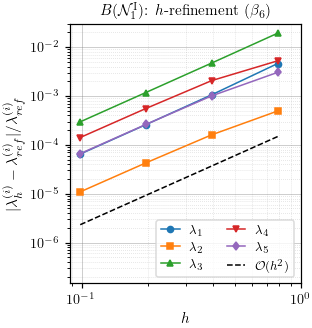

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


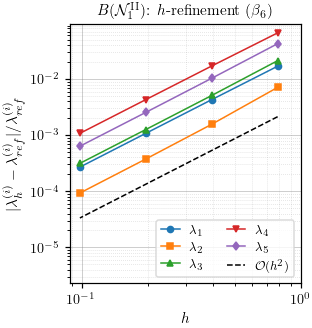

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


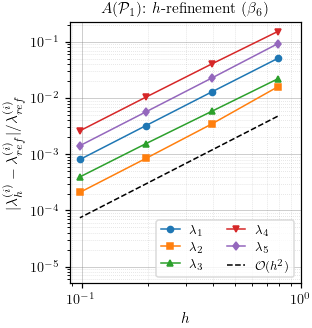

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


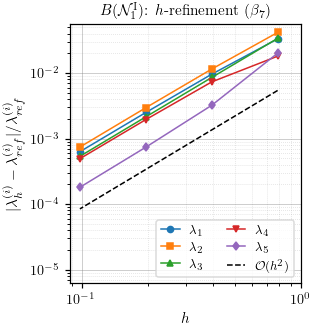

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


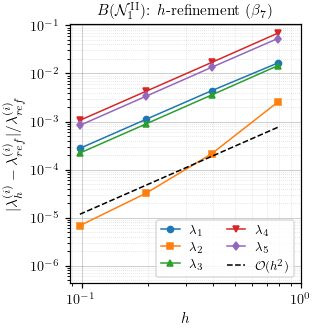

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


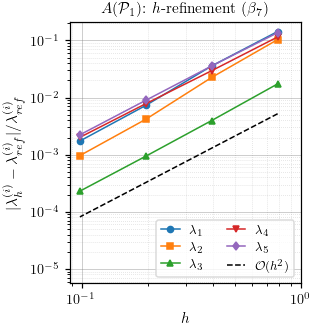

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


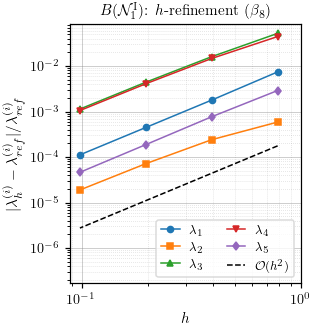

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


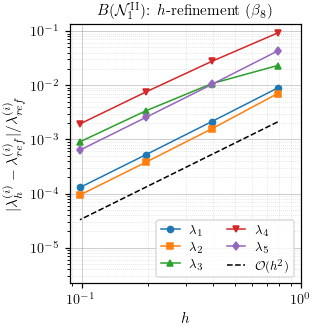

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


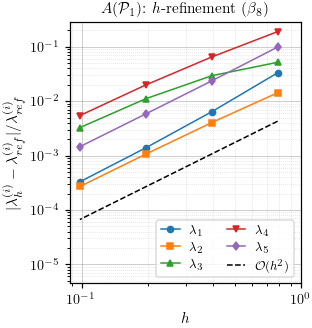

In [33]:
#: The panels the document uses: the rough shears, on the two formulations whose
#: hypotheses differ.  The table above carries all three formulations.

for key in PANEL_FIELDS:
    for f in PANEL_FORMS:
        df = h_tables[(f, key)]
        h = df["h"].to_numpy()
        e = [df[c].to_numpy() for c in EIG_COLS]
        # The reference slope is anchored a factor 0.30 below the lowest curve so
        # that it sits beside the data rather than under it.
        ref = 0.30 * min(y[0] for y in e)
        conv_panel(
            h, [(rf"$\lambda_{{{j+1}}}$", e[j]) for j in range(5)],
            refs=[(h, ref * (h / h[0]) ** 2,
                   dict(ls="--", label=r"$\mathcal{O}(h^{2})$"))],
            xlabel=r"$h$", ylabel=REL_ERR,
            title=rf"{TEX1[f]}: $h$-refinement ({BETA_TEX[key]})",
            xmax_at_least=1.0, name=f"breg1_h_{key}_{TAG[f]}")

In [34]:
P_LEVELS = (1, 2, 3, 4)
N_PREF = 6

In [36]:
def p_study(form, field_key, levels=P_LEVELS, N=N_PREF, Rm=1.0, alpha=None):
    """Errors of the first five eigenvalues as the degree rises on a fixed mesh."""
    
    # 1. Conditionally load exact spectra for b6, otherwise use the numerical reference
    if field_key == "b6":
        # Compute exact eigenvalues dynamically for the given Rm
        exact_df = compute_exact_spectra(Rm=Rm, num_modes=5, xtol=1e-15, rtol=1e-15)
        ref = exact_df['beta_6'].values
    else:
        ref = reference_for(field_key, alpha)
        
    mesh = crisscross_mesh(N)
    beta = (FIELDS[field_key](mesh) if alpha is None
            else FIELDS[field_key](mesh, alpha=alpha))
            
    rows = []
    for r in levels:
        res = solve_form(form, mesh, r, beta=beta, Rm=Rm, nev=25, field=field_key)
        got = assign(ref, res.values)
        rows.append(dict(r=r, dof=res.size,
                         **{EIG_COLS[j]: abs(got[j] - ref[j]) / abs(ref[j])
                            for j in range(5)},
                         # Replaced res.kappa1 with the exact MUMPS COND1 dictionary fetch
                         **{r"$\kappa_1$": res.kappa.get("MUMPS COND1", np.nan)}))
                         
    return pd.DataFrame(rows).set_index("r")

In [37]:
p_tables = {(f, "b6"): p_study(f, "b6") for f in FORMS}
for f in FORMS:
    display(show(p_tables[(f, "b6")], default="{:.3e}",
                 rules=[("dof", "{:.0f}"), (r"$\kappa_1$", "{:.2e}")],
                 caption=rf"$p$-refinement, **{f}**, field `b6`, $N = {N_PREF}$, $R_m = 1$"))

**$p$-refinement, **B(N1)**, field `b6`, $N = 6$, $R_m = 1$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,313,1.968e-03,2.702e-04,8.535e-03,3.216e-03,1.679e-03,1.29e+03
2,1057,3.981e-07,3.046e-05,3.204e-05,1.416e-04,1.587e-05,7.25e+03
3,2233,9.706e-09,8.084e-08,9.343e-08,1.113e-06,5.497e-07,1.03e+04
4,3841,1.450e-11,1.628e-10,2.061e-10,4.506e-09,4.565e-09,9.62e+03


**$p$-refinement, **B(N2)**, field `b6`, $N = 6$, $R_m = 1$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,769,7.581e-03,2.817e-03,9.147e-03,3.014e-02,1.856e-02,8.33e+02
2,1801,1.827e-05,4.476e-05,4.862e-07,3.004e-04,3.983e-05,2.06e+03
3,3265,2.452e-08,1.055e-07,1.121e-07,1.652e-06,7.388e-07,1.01e+04
4,5161,2.106e-11,1.933e-10,2.898e-10,5.641e-09,5.539e-09,1.86e+04


**$p$-refinement, **A(P)**, field `b6`, $N = 6$, $R_m = 1$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,86,2.270e-02,5.950e-03,9.025e-03,6.854e-02,3.867e-02,4.75e+01
2,314,5.147e-05,9.173e-05,1.498e-05,6.728e-04,1.067e-04,9.90e+01
3,686,4.325e-08,1.925e-07,2.035e-07,3.072e-06,1.312e-06,1.80e+02
4,1202,3.774e-11,3.430e-10,4.311e-10,1.026e-08,9.510e-09,3.07e+02


In [38]:
p_tables = {(f, "b7"): p_study(f, "b7") for f in FORMS}
for f in FORMS:
    display(show(p_tables[(f, "b7")], default="{:.3e}",
                 rules=[("dof", "{:.0f}"), (r"$\kappa_1$", "{:.2e}")],
                 caption=rf"$p$-refinement, **{f}**, field `b7`, $N = {N_PREF}$, $R_m = 1$"))

**$p$-refinement, **B(N1)**, field `b7`, $N = 6$, $R_m = 1$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,313,1.637e-02,1.975e-02,1.508e-02,1.145e-02,6.546e-03,4.42e+03
2,1057,2.454e-06,4.169e-05,9.244e-06,2.725e-04,6.721e-05,2.19e+04
3,2233,7.248e-08,1.950e-06,7.838e-08,4.943e-07,2.174e-07,3.75e+04
4,3841,1.010e-08,1.733e-07,3.803e-08,3.162e-09,2.235e-07,6.34e+04


**$p$-refinement, **B(N2)**, field `b7`, $N = 6$, $R_m = 1$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,769,7.479e-03,6.513e-04,6.305e-03,3.046e-02,2.340e-02,3.43e+03
2,1801,1.398e-05,1.763e-05,2.163e-06,3.147e-04,1.012e-04,1.52e+04
3,3265,1.017e-07,6.218e-08,1.113e-07,1.676e-06,1.738e-07,3.65e+04
4,5161,3.741e-10,2.902e-08,5.351e-09,1.053e-08,4.153e-08,6.59e+04


**$p$-refinement, **A(P)**, field `b7`, $N = 6$, $R_m = 1$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,86,9.458e-02,6.852e-02,6.988e-03,4.949e-02,6.068e-02,2.33e+02
2,314,1.873e-04,1.430e-04,6.762e-05,5.006e-04,3.912e-04,7.43e+02
3,686,1.202e-06,1.130e-06,3.465e-07,7.195e-06,8.300e-06,1.49e+03
4,1202,9.144e-08,2.813e-07,6.258e-08,7.391e-08,3.237e-07,2.67e+03


In [39]:
p_tables = {(f, "b8"): p_study(f, "b8") for f in FORMS}
for f in FORMS:
    display(show(p_tables[(f, "b8")], default="{:.3e}",
                 rules=[("dof", "{:.0f}"), (r"$\kappa_1$", "{:.2e}")],
                 caption=rf"$p$-refinement, **{f}**, field `b8`, $N = {N_PREF}$, $R_m = 1$"))

**$p$-refinement, **B(N1)**, field `b8`, $N = 6$, $R_m = 1$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,313,3.234e-03,4.218e-04,2.631e-02,2.326e-02,1.407e-03,7.06e+02
2,1057,6.623e-05,4.669e-05,1.094e-04,2.853e-04,9.752e-06,3.57e+03
3,2233,2.838e-06,2.301e-07,8.218e-07,4.838e-07,3.791e-07,5.09e+03
4,3841,3.032e-07,1.769e-09,5.247e-07,8.269e-07,8.117e-09,8.62e+03


**$p$-refinement, **B(N2)**, field `b8`, $N = 6$, $R_m = 1$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,769,3.701e-03,2.798e-03,1.572e-02,4.556e-02,1.858e-02,4.27e+02
2,1801,2.588e-05,4.337e-05,2.385e-04,3.442e-04,4.090e-05,1.52e+03
3,3265,5.747e-07,1.150e-07,5.430e-07,9.448e-08,7.369e-07,4.57e+03
4,5161,6.736e-08,1.845e-09,1.231e-07,1.908e-07,6.289e-09,6.75e+03


**$p$-refinement, **A(P)**, field `b8`, $N = 6$, $R_m = 1$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,86,1.365e-02,5.904e-03,3.902e-02,9.962e-02,4.050e-02,5.94e+01
2,314,2.250e-04,1.964e-06,9.451e-04,1.116e-03,1.046e-04,1.27e+02
3,686,1.352e-07,3.592e-06,1.680e-05,2.125e-05,2.472e-06,2.42e+02
4,1202,2.920e-07,3.838e-09,6.538e-07,9.411e-07,5.772e-09,4.25e+02


**Final relative errors at the maximum polynomial degree ($p=4$) and condition numbers, for all three $L^\infty\setminus W^{1,\infty}$ fields and formulations ($R_m = 1$).**

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


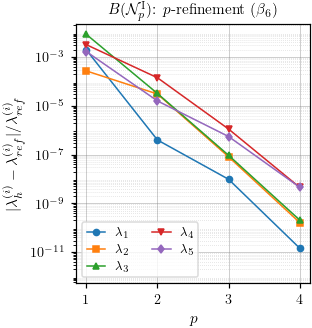

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


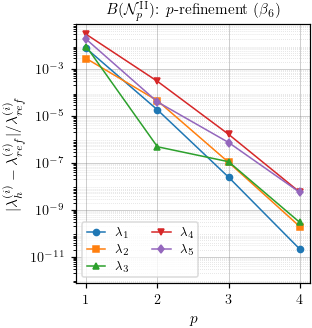

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


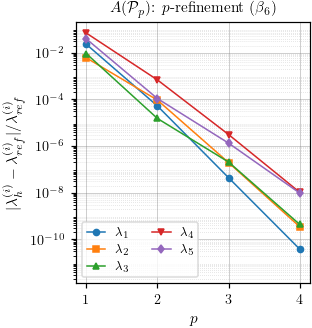

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


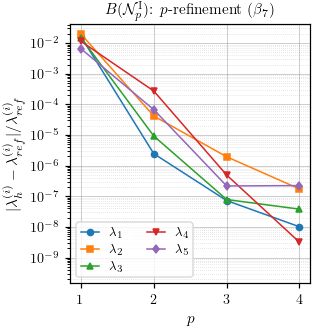

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


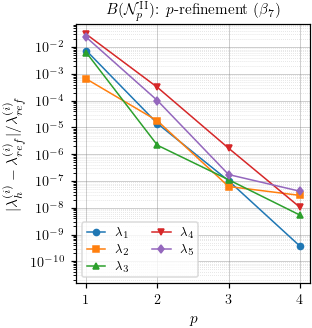

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


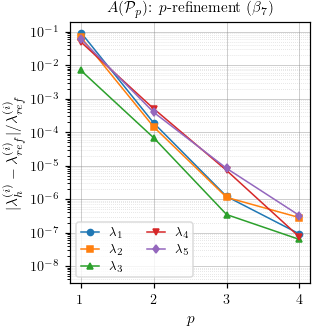

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


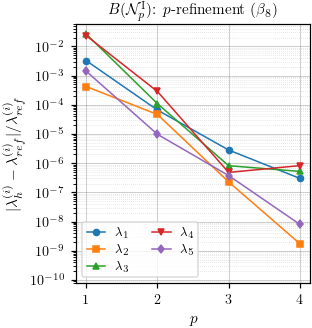

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


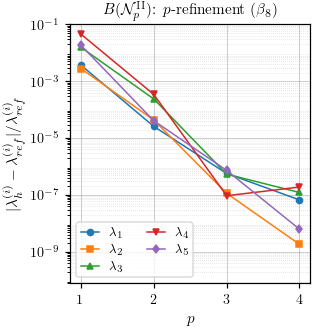

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


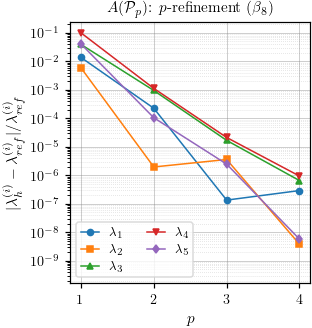

In [41]:
# 1. Generate the summary table of final errors at the highest p-level
rows_p = []
for key in ROUGH:
    for form in FORMS:
        # Compute the p_study if it hasn't been generated yet
        if (form, key) not in p_tables:
            p_tables[(form, key)] = p_study(form, key)
            
        df = p_tables[(form, key)]
        row = {"field": key, "formulation": form}
        
        # Report the final relative error at the highest p-level instead of a rate
        for col in EIG_COLS:
            row[f"error {col}"] = df[col].iloc[-1]
            
        row[r"$\kappa_1$ (finest)"] = df[r"$\kappa_1$"].iloc[-1]
        rows_p.append(row)

df_errors_p = pd.DataFrame(rows_p).set_index(["field", "formulation"])

show(df_errors_p, default="{:.2e}", rules=[(r"$\kappa_1$ (finest)", "{:.2e}")],
     caption=r"Final relative errors at the maximum polynomial degree ($p=4$) and condition numbers, "
             r"for all three $L^\infty\setminus W^{1,\infty}$ fields and formulations ($R_m = 1$).")


# 2. Plot the convergence figures
for key in ROUGH:
    for f in FORMS:
        df = p_tables[(f, key)]
        conv_panel(
            np.asarray(df.index, float),
            [(rf"$\lambda_{{{j+1}}}$", df[EIG_COLS[j]].to_numpy()) for j in range(5)],
            xlabel=r"$p$", ylabel=REL_ERR,
            title=rf"{TEXP[f]}: $p$-refinement ({BETA_TEX[key]})",
            logx=False, xticks=P_LEVELS, numticks=40, legend_loc="lower left",
            name=f"breg1_p_{key}_{TAG[f]}")

## Figure 4.7: β7 pseudospectra across Rm ∈ {1, 10, 20}


$\varepsilon$-pseudospectra of $A(\mathcal{P}_3)$, $B(\mathcal{N}^{\mathrm{II}}_3)$, $B(\mathcal{N}^{\mathrm{I}}_3)$ under $\beta_7$ at $R_m = 1, 10, 20$; criss-cross $N = 64$, $p = 3$, $\tau = 0.9/R_m$, window $[0,12]\times[-4,4]$, one shared colour scale. `run_ps` is called without `nev`, so the eigenvalue count is its default (200 from Setup; the `PS_NEV = 300` set here does not reach it, see Notes). Writes `breg1_ps_b7_2x3`.


Rm =  1.0   cell Peclet = 0.02
Rm = 10.0   cell Peclet = 0.25
Rm = 20.0   cell Peclet = 0.49
shared colour scale: [1.0e-10, 1.0e+01]


**Projection diagnostics for the $\beta_7$ scan across $R_m$**

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


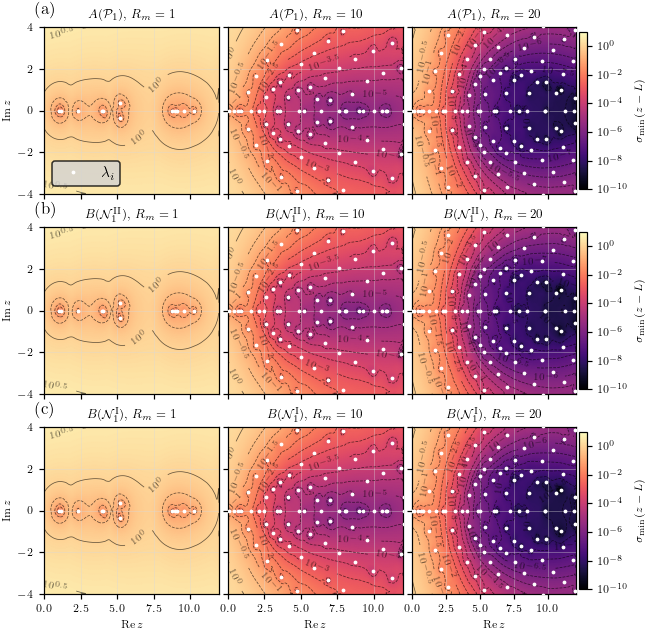

Condition numbers (kappa1):
  A(P)   Rm=1    : 1.322e+07
  A(P)   Rm=10   : 3.006e+08
  A(P)   Rm=20   : 1.179e+09
  B(N2)  Rm=1    : 4.578e+09
  B(N2)  Rm=10   : 2.775e+08
  B(N2)  Rm=20   : 1.692e+08
  B(N1)  Rm=1    : 4.774e+09
  B(N1)  Rm=10   : 2.951e+08
  B(N1)  Rm=20   : 1.792e+08


In [19]:
PS_N, PS_R, PS_NEV = 64,3, 300
PS_WINDOW = ((0.0, 22.0), (-5.0, 5.0))

mesh_ps = crisscross_mesh(PS_N)

PS_WINDOW_B7 = ((0.0, 12.0), (-4.0, 4.0))
# Cell Peclet: ||beta_8|| = sqrt(2), so N >~ pi*sqrt(2)*Rm/2 keeps the
# unstabilised discretisation honest.  N = 20 supports Rm up to about 9.
for Rm in (1.0, 10, 20):
    print(f"Rm = {Rm:4.1f}   cell Peclet = "
          f"{(np.pi / PS_N) * FIELDS['b7'].sup * Rm / 2:.2f}")
ps_b7 = {(f, Rm): run_ps(f, "b7", Rm=Rm, window=PS_WINDOW_B7)
         for Rm in (1,10,20) for f in FORMS}

# One colour scale for all six panels -- both formulations and both Reynolds
# numbers.  Sharing across Rm compares a formulation with itself as a physical
# parameter changes; sharing across formulations is legitimate too now that each
# panel is whitened against the metric of its own field (Section 3.5), and it is
# what makes the drop in level with Rm readable as one figure.
PS_SCALE_B7 = ps.shared_scale(ps_b7)
print(f"shared colour scale: [{PS_SCALE_B7[0]:.1e}, {PS_SCALE_B7[1]:.1e}]")
show(ps.diagnostics_frame(ps_b7.values(), keys=("form", "Rm")), default="{:.3e}",
     rules=[("N", "{:.0f}"), ("m", "{:.0f}"), ("eigs in window", "{:.0f}"),
            ("max |Im| in window", "{:.2e}"),
            ("max |Im| all ritz", "{:.2e}"),
            ("metric cond", "{:.1e}"), ("Rm", "{:.1f}")],
     caption=r"Projection diagnostics for the $\beta_7$ scan across $R_m$")
# Figure 4.7: two formulations down the rows, three Reynolds numbers across.
# One window and one colour scale for all six, so the drop in level with R_m is
# readable as one figure.
PS_RMS = [1.0, 10, 20.0]
ps_grid([[ps_b7[(f, rm)] for rm in PS_RMS] for f in PANEL_FORMS[::-1]],
        [[rf"{TEX1[f]}, $R_m={rm:g}$" for rm in PS_RMS] for f in PANEL_FORMS[::-1]],
        "breg1_ps_b7_2x3", scale=PS_SCALE_B7, row_height=0.325, labels="row")

print("Condition numbers (kappa1):")
for f in PANEL_FORMS[::-1]:
    for rm in PS_RMS:
        print(f"  {f:6s} Rm={rm:<5g}: {ps_b7[(f, rm)]['kappa1']:.3e}")

## Figure 4.8: h-refinement for A(P1) under the L^q vortex β9


First the exponents `ALPHAS` and the cross-formulation reference spectra for $\beta_{11}$ and $\beta_9(\alpha)$, $\alpha \in \{1.0, 1.25, 1.5, 1.75\}$ ($R_m = 20$, $N = 64$, $p = 3$, $\tau = 0.9$, 100 eigenvalues; that table is Table A.10), then $h$-refinement at $p = 1$, $N \in \{8,16,32,64\}$, $R_m = 20$, $\tau = 0.9$, 25 eigenvalues for all three formulations. Writes `breg1_h_b9_a1p{0,25,5,75}_*` and `breg1_h_b11_*`; the thesis figure is `breg1_h_b9_a1p0_AP.eps` + `breg1_h_b9_a1p75_AP.eps`, the full grid is Figure A.8.


In [23]:
ALPHAS = (1.0, 1.25, 1.5, 1.75)
ALPHA_MAIN = 1.5

# What the discretisation actually sees: the largest cell-average of |beta|.
print("effective magnitude of the vortex, by mesh and exponent")
print(f"{'N':>5s}" + "".join(f"{'a=' + format(a, '.2f'):>12s}" for a in ALPHAS))
for N in (8, 16, 32):
    mesh_e = crisscross_mesh(N)
    Q0 = FunctionSpace(mesh_e, "DG", 0)
    line = f"{N:5d}"
    for a in ALPHAS:
        b = FIELDS["b9"](mesh_e, alpha=a)
        mag = Function(Q0).interpolate(sqrt(dot(b, b)))
        line += f"{float(np.abs(mag.dat.data_ro).max()):12.2f}"
    print(line)

effective magnitude of the vortex, by mesh and exponent
    N      a=1.00      a=1.25      a=1.50      a=1.75
    8        1.00        1.48        2.20        3.26
   16        1.00        1.76        3.11        5.48
   32        1.00        2.10        4.40        9.22


In [26]:
# 1. Define the b11 field and add it to FIELDS (if you haven't already)
def _b11(mesh, L, delta=1e-12):
    x, y = SpatialCoordinate(mesh)
    xc = yc = Constant(L / 2)
    r = sqrt((x - xc)**2 + (y - yc)**2 + Constant(delta))
    return as_vector([ln(r), ln(r)])

FIELDS["b11"] = Field("b11", r"$(\ln r_0, \ln r_0)$", r"$\bigcap_{p<\infty} L^p \setminus L^\infty$", False, False, None, _b11)

# 2. Setup the cross-validation
N_REF = 64
p = 3
RM_REF = 20
tau = 0.9
n_eigs = 100
nev = 100

mesh_ref_lp = crisscross_mesh(N_REF)
ref_runs_lp = {}

# Combine "ln" with your existing ALPHAS tuple (1.0, 1.25, 1.5, 1.75)
TEST_CASES = ["ln"] + list(ALPHAS)

print("Starting high-order cross-validation...")
for val in TEST_CASES:
    # Route the correct field building based on the current test case
    print(val)
    if val == "ln":
        beta_val = FIELDS["b11"](mesh_ref_lp)
        field_name = "b11"
        alpha_arg = None
    else:
        beta_val = FIELDS["b9"](mesh_ref_lp, alpha=val)
        field_name = "b9"
        alpha_arg = val
        
    for form in FORMS:
        print(form)
        # r=3 is the 3rd positional argument. Rm=1.0 is passed explicitly by keyword.
        ref_runs_lp[(val, form)] = solve_form(form, mesh_ref_lp, p, 
                                            Rm=RM_REF, tau=tau, beta=beta_val,
                                            nev=nev, n_eigs=n_eigs, field=field_name,
                                            alpha=alpha_arg)
        
    stack = np.array([ref_runs_lp[(val, f)].values[:n_eigs] for f in FORMS])
    REFERENCE_LP[(field_name, val)] = stack.mean(axis=0)

rows = []
for val in TEST_CASES:
    stack = np.array([ref_runs_lp[(val, f)].values[:n_eigs] for f in FORMS])
    sprd = spread(stack)
    
    # 1. Append the 5 eigenvalue rows with explicit LaTeX headers
    for j in range(n_eigs):
        rows.append(dict(alpha=val, j=str(j + 1),
                         **{r"$B(\mathcal{N}_3^{\mathrm{I}})$": stack[0, j], 
                            r"$B(\mathcal{N}_3^{\mathrm{II}})$": stack[1, j],
                            r"$A(\mathcal{P}_3)$": stack[2, j], 
                            "Spread": sprd[j],
                            "Digits": agreeing_digits(stack[:, j])}))
    
    # 2. Extract MUMPS COND1 condition numbers
    k_bn1 = ref_runs_lp[(val, FORMS[0])].kappa.get("MUMPS COND1", np.nan)
    k_bn2 = ref_runs_lp[(val, FORMS[1])].kappa.get("MUMPS COND1", np.nan)
    k_ap  = ref_runs_lp[(val, FORMS[2])].kappa.get("MUMPS COND1", np.nan)
    
    # 3. Append the condition number as a dedicated 6th row for this alpha
    rows.append(dict(alpha=val, j=r"$\kappa(A-\tau M)$",
                     **{r"$B(\mathcal{N}_3^{\mathrm{I}})$": f"{k_bn1:.2e}" if pd.notna(k_bn1) else "-", 
                        r"$B(\mathcal{N}_3^{\mathrm{II}})$": f"{k_bn2:.2e}" if pd.notna(k_bn2) else "-",
                        r"$A(\mathcal{P}_3)$": f"{k_ap:.2e}" if pd.notna(k_ap) else "-", 
                        "Spread": "-",
                        "Digits": "-"}))

df_cv_lp = pd.DataFrame(rows).set_index(["alpha", "j"])

show(df_cv_lp, default="{:.5f}",
     # Note: Removed ("alpha", "{:.2f}") rule since "ln" is a string and will throw a float formatting error
     rules=[("Spread", "{:.2e}"), ("Digits", "{:.0f}")],
     caption=rf"Cross-validation for the $\ln$ field and $L^p$ vortex, $R_m = 100$, $N = {N_REF}$, "
             rf"$r = 3$, as the singularity strengthens. $\kappa$ denotes the MUMPS COND1 estimate.")

Starting high-order cross-validation...
ln
B(N1)
B(N2)
A(P)
1.0
B(N1)
B(N2)
A(P)
1.25
B(N1)
B(N2)
A(P)
1.5
B(N1)
B(N2)
A(P)
1.75
B(N1)
B(N2)
A(P)


**Cross-validation for the $\ln$ field and $L^p$ vortex, $R_m = 100$, $N = 64$, $r = 3$, as the singularity strengthens. $\kappa$ denotes the MUMPS COND1 estimate.**

$B(\mathcal{N}_3^{\mathrm{I}})$  \
alpha j                                                    
ln    1                                          0.04560   
      2                                          0.19617   
      3                                 0.57286+0.14089i   
      4                                 0.57286-0.14089i   
      5                                 0.65330+0.29364i   
      6                                 0.65330-0.29364i   
      7                                          0.86264   
      8                                 0.99907+0.55342i   
      9                                 0.99907-0.55342i   
      10                                1.11175+0.65671i   
      11                                1.11175-0.65671i   
      12                                         1.12186   
      13                                1.49256+0.84154i   
      14                                1.49256-0.84154i   
      15                                1.54897+0.32473i   
      16                                1.54897-0.32473i   
      17                                1.71926+0.99263i   
      18                                1.71926-0.99263i   
      19                                1.80546+0.35617i   
      20                                1.80546-0.35617i   
      21                                2.08621+1.10721i   
      22                                2.08621-1.10721i   
      23                                         2.31218   
      24                                2.32540+0.60673i   
      25                                2.32540-0.60673i   
      26                                         2.36218   
      27                                2.48862+1.27138i   
      28                                2.48862-1.27138i   
      29                                2.63386+0.70050i   
      30                                2.63386-0.70050i   
      31                                         2.69600   
      32                                2.88403+1.34177i   
      33                                2.88403-1.34177i   
      34                                3.01860+0.81994i   
      35                                3.01860-0.81994i   
      36                                3.22133+0.35804i   
      37                                3.22133-0.35804i   
      38                                3.45911+1.43517i   
      39                                3.45911-1.43517i   
      40                                3.50612+1.03795i   
      41                                3.50612-1.03795i   
      42                                3.61549+0.43772i   
      43                                3.61549-0.43772i   
      44                                3.64760+1.02032i   
      45                                3.64760-1.02032i   
      46                                3.73981+0.72201i   
      47                                3.73981-0.72201i   
      48                                3.96469+1.61364i   
      49                                3.96469-1.61364i   
      50                                3.99301+1.11540i   
      51                                3.99301-1.11540i   
      52                                         4.12416   
      53                                4.40743+0.59419i   
      54                                4.40743-0.59419i   
      55                                4.53247+1.21334i   
      56                                4.53247-1.21334i   
      57                                4.62370+1.73414i   
      58                                4.62370-1.73414i   
      59                                4.64949+0.69404i   
      60                                4.64949-0.69404i   
      61                                4.65368+0.10907i   
      62                                4.65368-0.10907i   
      63                                4.75798+0.18775i   
      64                                4.75798-0.18775i   
      65                                4.97036+1.38280i   
     


--- Processing: $\beta_{11}$ ($\ln$ field) ---


**$h$-refinement, **B(N1)**, $\beta_{11}$ ($\ln$ field), $r = 1$, $R_m = 20$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
8,0.39270,2.731e-03,--,1.590e-03,--,2.390e-01,--,3.441e-01,--,9.989e-02,--,2.56e+03
16,0.19635,1.849e-03,0.56,2.358e-03,-0.57,2.239e-02,3.42,2.239e-02,3.94,8.086e-03,3.63,4.78e+03
32,0.09817,6.499e-04,1.51,7.442e-04,1.66,4.480e-03,2.32,4.480e-03,2.32,1.529e-03,2.40,2.28e+04
64,0.04909,1.760e-04,1.88,1.958e-04,1.93,1.058e-03,2.08,1.058e-03,2.08,3.558e-04,2.10,9.45e+04


**$h$-refinement, **B(N2)**, $\beta_{11}$ ($\ln$ field), $r = 1$, $R_m = 20$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
8,0.39270,3.724e-02,--,6.608e-02,--,5.465e-02,--,5.465e-02,--,4.054e-02,--,3.14e+03
16,0.19635,2.070e-02,0.85,1.317e-02,2.33,8.936e-03,2.61,8.936e-03,2.61,7.974e-03,2.35,7.05e+03
32,0.09817,4.858e-03,2.09,3.105e-03,2.08,1.956e-03,2.19,1.956e-03,2.19,1.847e-03,2.11,2.57e+04
64,0.04909,1.194e-03,2.02,7.650e-04,2.02,4.730e-04,2.05,4.730e-04,2.05,4.529e-04,2.03,9.79e+04


**$h$-refinement, **A(P)**, $\beta_{11}$ ($\ln$ field), $r = 1$, $R_m = 20$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
8,0.39270,7.323e-01,--,3.607e-01,--,2.770e-01,--,3.411e-01,--,2.515e-01,--,1.22e+03
16,0.19635,6.555e-02,3.48,4.628e-02,2.96,9.268e-02,1.58,9.268e-02,1.88,5.988e-02,2.07,1.53e+03
32,0.09817,1.520e-02,2.11,1.058e-02,2.13,1.593e-02,2.54,1.593e-02,2.54,1.125e-02,2.41,7.31e+03
64,0.04909,3.742e-03,2.02,2.603e-03,2.02,3.735e-03,2.09,3.735e-03,2.09,2.666e-03,2.08,3.00e+04


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


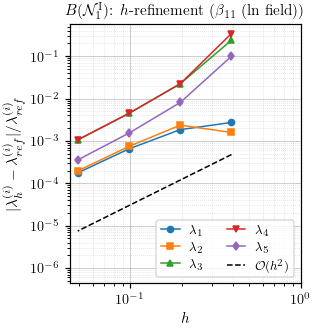

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


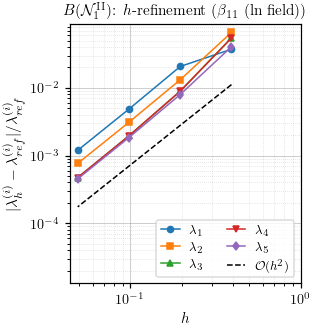

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


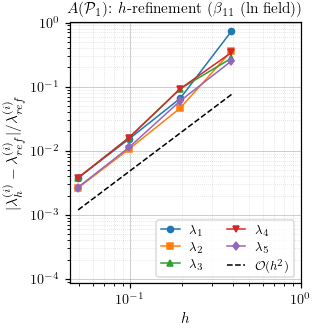


--- Processing: $\beta_9$, $\alpha = 1.0$ ---


**$h$-refinement, **B(N1)**, $\beta_9$, $\alpha = 1.0$, $r = 1$, $R_m = 20$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
8,0.39270,8.315e-03,--,8.315e-03,--,3.996e-02,--,7.239e-03,--,7.239e-03,--,6.60e+02
16,0.19635,1.203e-03,2.79,1.203e-03,2.79,3.606e-03,3.47,1.854e-03,1.97,1.854e-03,1.97,3.41e+02
32,0.09817,2.518e-04,2.26,2.518e-04,2.26,5.224e-04,2.79,4.480e-04,2.05,4.480e-04,2.05,1.00e+03
64,0.04909,6.009e-05,2.07,6.009e-05,2.07,1.080e-04,2.27,1.109e-04,2.01,1.109e-04,2.01,3.68e+03


**$h$-refinement, **B(N2)**, $\beta_9$, $\alpha = 1.0$, $r = 1$, $R_m = 20$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
8,0.39270,2.879e-03,--,2.879e-03,--,1.995e-02,--,4.683e-03,--,4.683e-03,--,1.40e+03
16,0.19635,8.210e-04,1.81,8.210e-04,1.81,4.390e-03,2.18,1.221e-03,1.94,1.221e-03,1.94,5.38e+02
32,0.09817,2.101e-04,1.97,2.101e-04,1.97,1.065e-03,2.04,3.055e-04,2.00,3.055e-04,2.00,1.19e+03
64,0.04909,5.279e-05,1.99,5.279e-05,1.99,2.643e-04,2.01,7.634e-05,2.00,7.634e-05,2.00,3.92e+03


**$h$-refinement, **A(P)**, $\beta_9$, $\alpha = 1.0$, $r = 1$, $R_m = 20$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
8,0.39270,2.215e-03,--,2.215e-03,--,1.131e-02,--,4.913e-03,--,4.913e-03,--,1.70e+02
16,0.19635,5.093e-04,2.12,5.093e-04,2.12,3.582e-03,1.66,1.163e-03,2.08,1.163e-03,2.08,1.85e+03
32,0.09817,9.304e-05,2.45,9.304e-05,2.45,1.068e-03,1.75,3.196e-04,1.86,3.196e-04,1.86,3.12e+03
64,0.04909,2.119e-05,2.13,2.119e-05,2.13,2.823e-04,1.92,8.146e-05,1.97,8.146e-05,1.97,1.05e+04


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


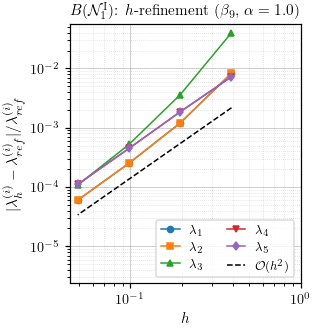

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


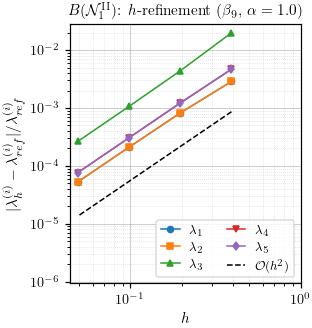

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


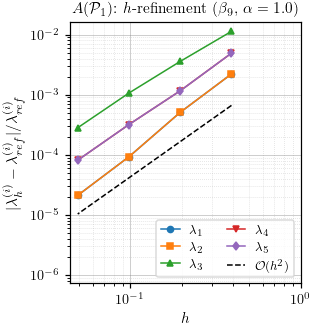


--- Processing: $\beta_9$, $\alpha = 1.25$ ---


**$h$-refinement, **B(N1)**, $\beta_9$, $\alpha = 1.25$, $r = 1$, $R_m = 20$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
8,0.39270,8.307e-03,--,8.307e-03,--,3.904e-02,--,9.466e-03,--,9.466e-03,--,4.72e+02
16,0.19635,1.324e-03,2.65,1.324e-03,2.65,3.566e-03,3.45,2.158e-03,2.13,2.158e-03,2.13,1.60e+02
32,0.09817,2.854e-04,2.21,2.854e-04,2.21,4.877e-04,2.87,5.119e-04,2.08,5.119e-04,2.08,4.91e+02
64,0.04909,6.856e-05,2.06,6.856e-05,2.06,9.685e-05,2.33,1.261e-04,2.02,1.261e-04,2.02,1.71e+03


**$h$-refinement, **B(N2)**, $\beta_9$, $\alpha = 1.25$, $r = 1$, $R_m = 20$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
8,0.39270,3.197e-03,--,3.197e-03,--,1.923e-02,--,5.222e-03,--,5.222e-03,--,1.08e+02
16,0.19635,8.594e-04,1.90,8.594e-04,1.90,4.317e-03,2.16,1.353e-03,1.95,1.353e-03,1.95,2.10e+02
32,0.09817,2.178e-04,1.98,2.178e-04,1.98,1.053e-03,2.04,3.374e-04,2.00,3.374e-04,2.00,5.53e+02
64,0.04909,5.463e-05,2.00,5.463e-05,2.00,2.614e-04,2.01,8.425e-05,2.00,8.425e-05,2.00,1.82e+03


**$h$-refinement, **A(P)**, $\beta_9$, $\alpha = 1.25$, $r = 1$, $R_m = 20$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
8,0.39270,1.607e-03,--,1.607e-03,--,1.424e-02,--,6.592e-03,--,6.592e-03,--,1.97e+02
16,0.19635,2.720e-04,2.56,2.720e-04,2.56,4.149e-03,1.78,1.644e-03,2.00,1.644e-03,2.00,1.19e+03
32,0.09817,5.339e-05,2.35,5.339e-05,2.35,1.174e-03,1.82,4.362e-04,1.91,4.362e-04,1.91,2.45e+03
64,0.04909,1.311e-05,2.03,1.311e-05,2.03,3.063e-04,1.94,1.103e-04,1.98,1.103e-04,1.98,8.48e+03


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


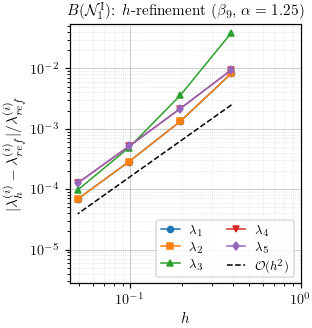

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


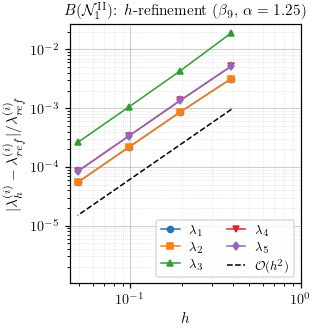

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


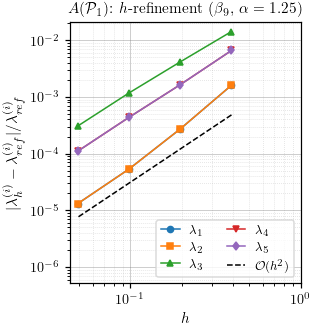


--- Processing: $\beta_9$, $\alpha = 1.5$ ---
  [!] Reference for ('b9', 1.5) missing. Generating high-order baseline now...


**$h$-refinement, **B(N1)**, $\beta_9$, $\alpha = 1.5$, $r = 1$, $R_m = 20$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
8,0.39270,8.297e-03,--,8.297e-03,--,4.072e-02,--,1.161e-02,--,1.161e-02,--,4.36e+02
16,0.19635,1.503e-03,2.46,1.503e-03,2.46,3.764e-03,3.44,2.480e-03,2.23,2.480e-03,2.23,2.70e+02
32,0.09817,3.321e-04,2.18,3.321e-04,2.18,4.745e-04,2.99,5.836e-04,2.09,5.836e-04,2.09,7.62e+02
64,0.04909,8.048e-05,2.04,8.048e-05,2.04,8.774e-05,2.43,1.434e-04,2.03,1.434e-04,2.03,2.71e+03


**$h$-refinement, **B(N2)**, $\beta_9$, $\alpha = 1.5$, $r = 1$, $R_m = 20$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
8,0.39270,3.190e-03,--,3.190e-03,--,1.881e-02,--,6.033e-03,--,6.033e-03,--,4.64e+03
16,0.19635,8.439e-04,1.92,8.439e-04,1.92,4.258e-03,2.14,1.515e-03,1.99,1.515e-03,1.99,3.54e+02
32,0.09817,2.158e-04,1.97,2.158e-04,1.97,1.040e-03,2.03,3.759e-04,2.01,3.759e-04,2.01,8.68e+02
64,0.04909,5.418e-05,1.99,5.418e-05,1.99,2.585e-04,2.01,9.374e-05,2.00,9.374e-05,2.00,2.87e+03


**$h$-refinement, **A(P)**, $\beta_9$, $\alpha = 1.5$, $r = 1$, $R_m = 20$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
8,0.39270,2.521e-03,--,2.521e-03,--,1.675e-02,--,8.236e-03,--,8.236e-03,--,2.50e+02
16,0.19635,1.905e-04,3.73,1.905e-04,3.73,4.682e-03,1.84,2.244e-03,1.88,2.244e-03,1.88,8.92e+02
32,0.09817,6.811e-05,1.48,6.811e-05,1.48,1.278e-03,1.87,5.833e-04,1.94,5.833e-04,1.94,2.02e+03
64,0.04909,1.874e-05,1.86,1.874e-05,1.86,3.300e-04,1.95,1.468e-04,1.99,1.468e-04,1.99,6.99e+03


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


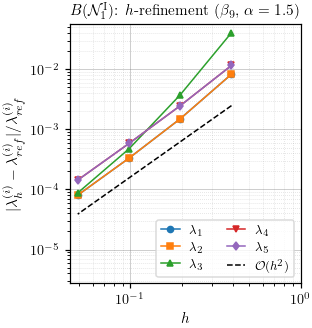

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


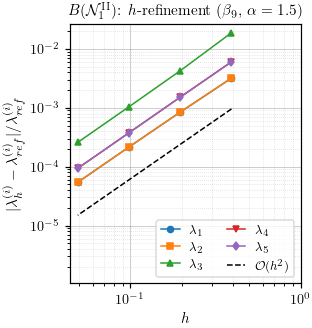

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


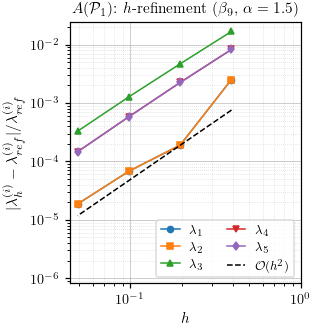


--- Processing: $\beta_9$, $\alpha = 1.75$ ---
  [!] Reference for ('b9', 1.75) missing. Generating high-order baseline now...


**$h$-refinement, **B(N1)**, $\beta_9$, $\alpha = 1.75$, $r = 1$, $R_m = 20$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
8,0.39270,8.908e-03,--,8.908e-03,--,4.539e-02,--,1.346e-02,--,1.346e-02,--,3.10e+02
16,0.19635,1.728e-03,2.37,1.728e-03,2.37,4.286e-03,3.40,2.786e-03,2.27,2.786e-03,2.27,2.51e+02
32,0.09817,3.990e-04,2.11,3.990e-04,2.11,5.027e-04,3.09,6.545e-04,2.09,6.545e-04,2.09,7.77e+02
64,0.04909,9.743e-05,2.03,9.743e-05,2.03,8.296e-05,2.60,1.607e-04,2.03,1.607e-04,2.03,2.75e+03


**$h$-refinement, **B(N2)**, $\beta_9$, $\alpha = 1.75$, $r = 1$, $R_m = 20$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
8,0.39270,2.516e-03,--,2.516e-03,--,1.909e-02,--,7.041e-03,--,7.041e-03,--,6.95e+04
16,0.19635,8.176e-04,1.62,8.176e-04,1.62,4.251e-03,2.17,1.695e-03,2.06,1.695e-03,2.06,3.52e+02
32,0.09817,2.080e-04,1.97,2.080e-04,1.97,1.031e-03,2.04,4.184e-04,2.02,4.184e-04,2.02,8.77e+02
64,0.04909,5.234e-05,1.99,5.234e-05,1.99,2.558e-04,2.01,1.042e-04,2.01,1.042e-04,2.01,2.91e+03


**$h$-refinement, **A(P)**, $\beta_9$, $\alpha = 1.75$, $r = 1$, $R_m = 20$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
8,0.39270,4.588e-03,--,4.588e-03,--,1.889e-02,--,9.979e-03,--,9.979e-03,--,3.73e+02
16,0.19635,5.380e-04,3.09,5.380e-04,3.09,5.173e-03,1.87,2.950e-03,1.76,2.950e-03,1.76,7.31e+02
32,0.09817,1.499e-04,1.84,1.499e-04,1.84,1.377e-03,1.91,7.588e-04,1.96,7.588e-04,1.96,1.75e+03
64,0.04909,3.866e-05,1.96,3.866e-05,1.96,3.530e-04,1.96,1.905e-04,1.99,1.905e-04,1.99,5.75e+03


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


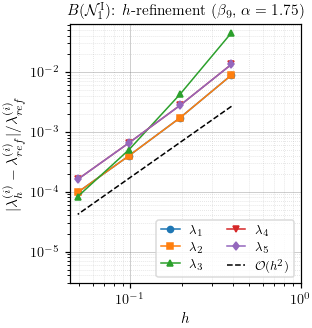

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


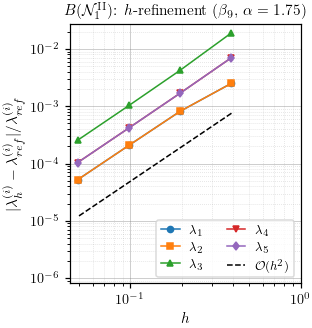

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


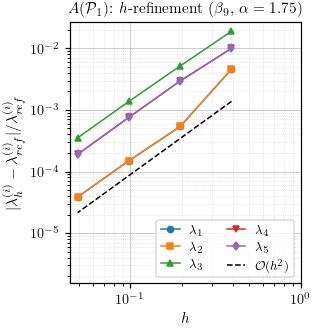

In [50]:
extended_levels = (8, 16, 32, 64)
TEST_CASES = ["ln"] + list(ALPHAS)

# 1. Update h_study with auto-reference generation and a SLEPc fail-safe
def h_study(form, field_key, levels=H_LEVELS, r=1, Rm=1, alpha=None, structure=False, tau=None):
    """Errors of the first five eigenvalues against the reference, level by level."""
    dict_val = "ln" if field_key == "b11" else alpha
    ref_key = (field_key, dict_val)
    
    if ref_key not in REFERENCE_LP:
        print(f"  [!] Reference for {ref_key} missing. Generating high-order baseline now...")
        mesh_ref = crisscross_mesh(64)
        beta_ref = FIELDS[field_key](mesh_ref) if alpha is None else FIELDS[field_key](mesh_ref, alpha=alpha)
        stack = []
        for f in FORMS:
            res = solve_form(f, mesh_ref, 3, Rm=Rm, tau=tau, beta=beta_ref, nev=50, n_eigs=5, field=field_key, alpha=alpha)
            stack.append(res.values[:5])
        REFERENCE_LP[ref_key] = np.array(stack).mean(axis=0)
        
    ref = REFERENCE_LP[ref_key]
        
    rows = []
    base_coarse = crisscross_mesh(N=levels[0]) if structure else unstructured_square_mesh(N=levels[0])
    hierarchy = MeshHierarchy(base_coarse, refinement_levels=len(levels) - 1)
    
    for level_idx, N_val in enumerate(levels):
        mesh = hierarchy[level_idx]
        beta = (FIELDS[field_key](mesh) if alpha is None else FIELDS[field_key](mesh, alpha=alpha))
        
        try:
            res = solve_form(form, mesh, r, beta=beta, Rm=Rm, tau=tau, nev=25, field=field_key)
            got = assign(ref, res.values)
            kappa_val = res.kappa.get("MUMPS COND1", np.nan)
            dof_val = res.size
        except Exception as e:
            print(f"      [!] SLEPc failed at N={N_val}. Inserting NaNs and continuing.")
            got = np.full(5, np.nan)
            kappa_val = np.nan
            dof_val = np.nan
            
        rows.append(dict(N=N_val, h=np.pi / N_val, dof=dof_val,
                         **{EIG_COLS[j]: abs(got[j] - ref[j]) / abs(ref[j]) for j in range(5)},
                         **{r"$\kappa_1$": kappa_val}))
                         
    return pd.DataFrame(rows).set_index("N")


# 2. Master Loop: Route parameters, display tables, and generate plots
for val in TEST_CASES:
    if val == "ln":
        field_key = "b11"
        alpha_arg = None
        field_tex = r"$\beta_{11}$ ($\ln$ field)"
        plot_name_base = "b11"
    else:
        field_key = "b9"
        alpha_arg = val
        field_tex = rf"{BETA_TEX['b9']}, $\alpha = {val}$"
        plot_name_base = f"b9_a{str(val).replace('.', 'p')}"

    print(f"\n--- Processing: {field_tex} ---")
    
    h_tables_lp = {f: h_study(f, field_key, levels=extended_levels, alpha=alpha_arg, 
                              Rm=20.0, tau=0.9, structure=True) for f in FORMS}

    for f in FORMS:
        display(show(rate_frame(h_tables_lp[f], EIG_COLS), default="{:.3e}",
                     rules=[("rate", "{:.2f}"), ("h", "{:.5f}"), (r"$\kappa_1$", "{:.2e}")],
                     caption=rf"$h$-refinement, **{f}**, {field_tex}, $r = 1$, $R_m = 20$"))

    for f in PANEL_FORMS:
        df = h_tables_lp[f].dropna() # Drop NaN rows so the plot doesn't break
        h_vals = df["h"].to_numpy()
        e_vals = [df[c].to_numpy() for c in EIG_COLS]
        ref_slope = 0.30 * min(y[0] for y in e_vals)
        
        conv_panel(
            h_vals, [(rf"$\lambda_{{{j+1}}}$", e_vals[j]) for j in range(5)],
            refs=[(h_vals, ref_slope * (h_vals / h_vals[0]) ** 2,
                   dict(ls="--", label=r"$\mathcal{O}(h^{2})$"))],
            xlabel=r"$h$", ylabel=REL_ERR,
            title=rf"{TEX1[f]}: $h$-refinement ({field_tex})",
            xmax_at_least=1.0, 
            name=f"breg1_h_{plot_name_base}_{TAG[f]}"
        )

## Figure 4.9: ε-pseudospectra for β9 ∈ L^q at Rm = 20


$\varepsilon$-pseudospectra under $\beta_9(\alpha)$, $\alpha \in \{0.1, 1.0, 1.9\}$, $R_m = 20$, criss-cross $N = 64$, $p = 3$, $\tau = 0.9/R_m = 0.045$, window $[0,12]\times[-6,6]$, `nev` = `run_ps` default (200). The first cell computes the six panels and the diagnostics table; the second redraws them with the thesis row labels and writes `vortex_ps_alpha_2x3_Rm20`. Both are parameter re-runs of the saved cells: the second formulation key `"B(N^I)"` is set to `"B(N2)"`, the pencil that key already selected (see Notes); no stored output.


In [ ]:
ALPHAS_PS = [0.1, 1.0, 1.9]
RM_FIXED = 20.0
PS_WINDOW_LP = ((0.0, 12.0), (-6.0, 6.0))
PS_FORMS = ["A(P)", "B(N2)"] 

print(f"Computing pseudospectra for Rm = {RM_FIXED}, N = 64, p = 3...")

# 1. Build the mesh explicitly, as run_ps expects 'mesh', not 'N'
mesh64 = crisscross_mesh(64)

# 2. Run the pseudospectra solver passing the mesh and r=3
ps_lp_alpha = {(f, a): run_ps(f, "b9", Rm=RM_FIXED, alpha=a, 
                              window=PS_WINDOW_LP, mesh=mesh64, r=3)
               for a in ALPHAS_PS for f in PS_FORMS}
               
PS_SCALE_LP_ALPHA = ps.shared_scale(ps_lp_alpha)
print(f"Shared colour scale: [{PS_SCALE_LP_ALPHA[0]:.1e}, {PS_SCALE_LP_ALPHA[1]:.1e}]")

display(show(ps.diagnostics_frame(ps_lp_alpha.values(), keys=("form", "alpha")),
             default="{:.3e}",
             rules=[("N", "{:.0f}"), ("m", "{:.0f}"), ("eigs in window", "{:.0f}"),
                    ("max |Im| in window", "{:.2e}"), ("max |Im| all ritz", "{:.2e}"),
                    ("metric cond", "{:.1e}"), ("alpha", "{:.2f}")],
             caption=rf"Projection diagnostics for the $\alpha$ ladder, "
                     rf"$R_m = {RM_FIXED:g}$, $N = 64$, $r = 3$"))

ps_grid([[ps_lp_alpha[(f, a)] for a in ALPHAS_PS] for f in PS_FORMS],
        [[rf"{TEX1.get(f, f)}, $\alpha={a:g}$" for a in ALPHAS_PS] for f in PS_FORMS],
        "vortex_ps_alpha_2x3_Rm20", scale=PS_SCALE_LP_ALPHA, row_height=0.325,
        labels="row")

print(f"Condition numbers (kappa1) at Rm = {RM_FIXED:g}:")
for f in PS_FORMS:
    for a in ALPHAS_PS:
        kappa = ps_lp_alpha[(f, a)].get('kappa1', np.nan)
        print(f"  {f:6s} alpha={a:<4g}: {kappa:.3e}")

In [ ]:
# Provide safe LaTeX strings specifically for the plotting engine
SAFE_TEX = {
    "A(P)": r"$A(\mathcal{P}_3)$", 
    "B(N2)": r"$B(\mathcal{N}^I_3)$"
}

print("Generating pseudospectra plots...")

# Rerun just the plotting function using the safe text
ps_grid([[ps_lp_alpha[(f, a)] for a in ALPHAS_PS] for f in PS_FORMS],
        [[rf"{SAFE_TEX[f]}, $\alpha={a:g}$" for a in ALPHAS_PS] for f in PS_FORMS],
        "vortex_ps_alpha_2x3_Rm20", scale=PS_SCALE_LP_ALPHA, row_height=0.325,
        labels="row")

print(f"Condition numbers (kappa1) at Rm = {RM_FIXED:g}:")
for f in PS_FORMS:
    for a in ALPHAS_PS:
        kappa = ps_lp_alpha[(f, a)].get('kappa1', np.nan)
        print(f"  {f:6s} alpha={a:<4g}: {kappa:.3e}")

# Appendix


## Table A.5: Exact eigenvalues for β6, β7, β8 at Rm = 5


Analytical eigenvalues at $R_m = 5$, first ten modes: the Table A.7 cell with `Rm=10.0` set to `Rm=5.0` (parameter re-run, no stored output).


In [ ]:
import numpy as np
from scipy.optimize import root_scalar
import pandas as pd

def compute_exact_spectra(Rm=1.0, num_modes=5, xtol=1e-14, rtol=1e-14, maxiter=100):
    eps = 1.0 / Rm
    
    k_roots = []
    for j in range(10):  
        left_bracket = 2 * j + 1 + 1e-9  
        right_bracket = 2 * j + 2        
        
        # Pass tolerances directly into root_scalar
        res = root_scalar(
            lambda k: np.tan(k * np.pi / 2) + 2 * eps * k, 
            bracket=[left_bracket, right_bracket], 
            method='brentq',
            xtol=xtol,       # Absolute tolerance for the root
            rtol=rtol,       # Relative tolerance for the root
            maxiter=maxiter  # Maximum number of iterations
        )
        
        # Optional: Raise an error if the algorithm failed to converge
        if not res.converged:
            raise ValueError(f"Root finder failed to converge for mode {j}: {res.flag}")
            
        k_roots.append(res.root)
        
    # 2. Generate candidate eigenvalues for beta_6
    b6_set1 = [eps * n**2 for n in range(1, 20)]
    b6_set2 = [eps * (4 * m**2 + n**2) + 1 / (4 * eps) for n in range(10) for m in range(1, 10)]
    b6_set3 = [eps * (k**2 + n**2) + 1 / (4 * eps) for n in range(10) for k in k_roots]
    
    b6_spectrum = sorted(b6_set1 + b6_set2 + b6_set3)[:num_modes]
    
    # 3. Generate candidate eigenvalues for beta_7
    b7_spectrum = sorted([eps * n**2 for n in range(1, num_modes + 1)])
    
    # 4. Generate candidate eigenvalues for beta_8 
    b8_set1 = [4 * eps * m**2 + 1 / (4 * eps) for m in range(1, 10)]
    b8_set2 = [eps * k**2 + 1 / (4 * eps) for k in k_roots]
    
    b8_spectrum = sorted(b8_set1 + b8_set2)[:num_modes]
    
    # 5. Tabulate the results
    df = pd.DataFrame({
        'Index': range(1, num_modes + 1),
        'beta_6': b6_spectrum,
        'beta_7': b7_spectrum,
        'beta_8': b8_spectrum
    })
    
    return df

# Force pandas to display 14 decimal places to match our tight tolerance
pd.set_option('display.precision', 14)

# Execute with custom precision
exact_table = compute_exact_spectra(Rm=5.0, num_modes=10, xtol=1e-15, rtol=1e-15)
print(exact_table.to_string(index=False))

## Table A.6: Formulation comparison for β6, β7, β8 at Rm = 5


The Setup reference pair, the solve re-run with `RM_ref = 5` ($N = 64$, $p = 3$, 200 eigenvalues, first ten shown; `tau` is not passed, so `solve_form` uses $\tau = 0.9/R_m = 0.18$, not the $\tau = 0.9$ of the thesis caption, see Notes; parameter re-run, no stored output) followed by the table cell verbatim (its caption literal still says $R_m = 1$, see Notes). Overwrites `REFERENCE`, which nothing below uses.


In [ ]:
N_REF, R_REF, NEV_REF = 64, 3, 200
N_show = 10          # matched against, even though only the first five are shown
RM_ref = 5

mesh_ref = crisscross_mesh(N_REF)
ref_runs, REFERENCE = {}, {}
for key in ROUGH:
    beta_ref = FIELDS[key](mesh_ref)
    for form in FORMS:
        ref_runs[(key, form)] = solve_form(form, mesh_ref, R_REF, beta=beta_ref, Rm = RM_ref,
                                           nev=NEV_REF, n_eigs=N_show, field=key)
    stack = np.array([ref_runs[(key, f)].values[:N_show] for f in FORMS])
    # The reference is the mean of the three: they agree to far better than the
    # discretisation error of anything measured against it.
    REFERENCE[key] = stack.mean(axis=0)

TEX3 = {"B(N1)": r"$B(\mathcal{N}_3^{\mathrm{I}})$",
        "B(N2)": r"$B(\mathcal{N}_3^{\mathrm{II}})$",
        "A(P)": r"$A(\mathcal{P}_3)$"}

In [ ]:

rows = []
for key in ROUGH:
    stack = np.array([ref_runs[(key, f)].values[:N_show] for f in FORMS])
    sprd = spread(stack)
    for j in range(N_show):
        rows.append(dict(field=BETA_TEX[key], mode=str(j + 1),
                         **{TEX3[f]: stack[i, j] for i, f in enumerate(FORMS)},
                         **{"Spread": sprd[j],
                            "Digits": agreeing_digits(stack[:, j])}))
    # The conditioning of the shifted pencil, as its own row under each field.
    kap = {f: ref_runs[(key, f)].kappa.get("MUMPS COND1", np.nan) for f in FORMS}
    rows.append(dict(field=BETA_TEX[key], mode=r"$\kappa(A-\tau M)$",
                     **{TEX3[f]: f"{kap[f]:.2e}" if pd.notna(kap[f]) else "--"
                        for f in FORMS},
                     **{"Spread": np.nan, "Digits": np.nan}))

df_cv = pd.DataFrame(rows).set_index(["field", "mode"])
show(df_cv, default="{:.9f}", rules=[("Spread", "{:.2e}"), ("Digits", "{:.0f}")],
     caption=rf"Comparison of the first five eigenvalues, spread and matching digits "
             rf"across the three discretisations for $\beta_6$, $\beta_7$ and "
             rf"$\beta_8$, at $R_m = 1$ on a uniform criss-cross grid "
             rf"($N = {N_REF}$) with $p = {R_REF}$. The MUMPS condition number "
             rf"$\kappa(A-\tau M)$ of the shifted pencil is given for each "
             rf"configuration, $\tau = 0.9$.")

## Table A.7: Exact eigenvalues for β6, β7, β8 at Rm = 10


Analytical eigenvalues at $R_m = 10$, first ten modes (the cell as saved).


In [7]:
import numpy as np
from scipy.optimize import root_scalar
import pandas as pd

def compute_exact_spectra(Rm=1.0, num_modes=5, xtol=1e-14, rtol=1e-14, maxiter=100):
    eps = 1.0 / Rm
    
    k_roots = []
    for j in range(10):  
        left_bracket = 2 * j + 1 + 1e-9  
        right_bracket = 2 * j + 2        
        
        # Pass tolerances directly into root_scalar
        res = root_scalar(
            lambda k: np.tan(k * np.pi / 2) + 2 * eps * k, 
            bracket=[left_bracket, right_bracket], 
            method='brentq',
            xtol=xtol,       # Absolute tolerance for the root
            rtol=rtol,       # Relative tolerance for the root
            maxiter=maxiter  # Maximum number of iterations
        )
        
        # Optional: Raise an error if the algorithm failed to converge
        if not res.converged:
            raise ValueError(f"Root finder failed to converge for mode {j}: {res.flag}")
            
        k_roots.append(res.root)
        
    # 2. Generate candidate eigenvalues for beta_6
    b6_set1 = [eps * n**2 for n in range(1, 20)]
    b6_set2 = [eps * (4 * m**2 + n**2) + 1 / (4 * eps) for n in range(10) for m in range(1, 10)]
    b6_set3 = [eps * (k**2 + n**2) + 1 / (4 * eps) for n in range(10) for k in k_roots]
    
    b6_spectrum = sorted(b6_set1 + b6_set2 + b6_set3)[:num_modes]
    
    # 3. Generate candidate eigenvalues for beta_7
    b7_spectrum = sorted([eps * n**2 for n in range(1, num_modes + 1)])
    
    # 4. Generate candidate eigenvalues for beta_8 
    b8_set1 = [4 * eps * m**2 + 1 / (4 * eps) for m in range(1, 10)]
    b8_set2 = [eps * k**2 + 1 / (4 * eps) for k in k_roots]
    
    b8_spectrum = sorted(b8_set1 + b8_set2)[:num_modes]
    
    # 5. Tabulate the results
    df = pd.DataFrame({
        'Index': range(1, num_modes + 1),
        'beta_6': b6_spectrum,
        'beta_7': b7_spectrum,
        'beta_8': b8_spectrum
    })
    
    return df

# Force pandas to display 14 decimal places to match our tight tolerance
pd.set_option('display.precision', 14)

# Execute with custom precision
exact_table = compute_exact_spectra(Rm=10.0, num_modes=10, xtol=1e-15, rtol=1e-15)
print(exact_table.to_string(index=False))

 Index           beta_6  beta_7            beta_8
     1 0.10000000000000     0.1  2.81756639258571
     2 0.40000000000000     0.4  2.90000000000000
     3 0.90000000000000     0.9  3.79781724506172
     4 1.60000000000000     1.6  4.10000000000000
     5 2.50000000000000     2.5  5.49358050314525
     6 2.81756639258571     3.6  6.10000000000000
     7 2.90000000000000     4.9  7.94514559403710
     8 2.91756639258571     6.4  8.90000000000000
     9 3.00000000000000     8.1 11.17441708468122
    10 3.21756639258571    10.0 12.50000000000000


## Table A.8: Formulation comparison for β6, β7, β8 at Rm = 10


Reference solve and table at $R_m = 10$ on the criss-cross mesh ($N = 64$, $p = 3$, 200 eigenvalues, first ten shown; `tau` is not passed, so the shift is $\tau = 0.9/R_m = 0.09$, not the $\tau = 0.9$ of the thesis caption, see Notes). The caption literal in the table cell still says $R_m = 1$ (see Notes).


In [9]:
N_REF, R_REF, NEV_REF = 64, 3, 200
N_show = 10          # matched against, even though only the first five are shown
RM_ref = 10

mesh_ref = crisscross_mesh(N_REF)
ref_runs, REFERENCE = {}, {}
for key in ROUGH:
    beta_ref = FIELDS[key](mesh_ref)
    for form in FORMS:
        ref_runs[(key, form)] = solve_form(form, mesh_ref, R_REF, beta=beta_ref, Rm = RM_ref,
                                           nev=NEV_REF, n_eigs=N_show, field=key)
    stack = np.array([ref_runs[(key, f)].values[:N_show] for f in FORMS])
    # The reference is the mean of the three: they agree to far better than the
    # discretisation error of anything measured against it.
    REFERENCE[key] = stack.mean(axis=0)

TEX3 = {"B(N1)": r"$B(\mathcal{N}_3^{\mathrm{I}})$",
        "B(N2)": r"$B(\mathcal{N}_3^{\mathrm{II}})$",
        "A(P)": r"$A(\mathcal{P}_3)$"}

In [10]:
rows = []
for key in ROUGH:
    stack = np.array([ref_runs[(key, f)].values[:N_show] for f in FORMS])
    sprd = spread(stack)
    for j in range(N_show):
        rows.append(dict(field=BETA_TEX[key], mode=str(j + 1),
                         **{TEX3[f]: stack[i, j] for i, f in enumerate(FORMS)},
                         **{"Spread": sprd[j],
                            "Digits": agreeing_digits(stack[:, j])}))
    # The conditioning of the shifted pencil, as its own row under each field.
    kap = {f: ref_runs[(key, f)].kappa.get("MUMPS COND1", np.nan) for f in FORMS}
    rows.append(dict(field=BETA_TEX[key], mode=r"$\kappa(A-\tau M)$",
                     **{TEX3[f]: f"{kap[f]:.2e}" if pd.notna(kap[f]) else "--"
                        for f in FORMS},
                     **{"Spread": np.nan, "Digits": np.nan}))

df_cv = pd.DataFrame(rows).set_index(["field", "mode"])
show(df_cv, default="{:.9f}", rules=[("Spread", "{:.2e}"), ("Digits", "{:.0f}")],
     caption=rf"Comparison of the first five eigenvalues, spread and matching digits "
             rf"across the three discretisations for $\beta_6$, $\beta_7$ and "
             rf"$\beta_8$, at $R_m = 1$ on a uniform criss-cross grid "
             rf"($N = {N_REF}$) with $p = {R_REF}$. The MUMPS condition number "
             rf"$\kappa(A-\tau M)$ of the shifted pencil is given for each "
             rf"configuration, $\tau = 0.9$.")

**Comparison of the first five eigenvalues, spread and matching digits across the three discretisations for $\beta_6$, $\beta_7$ and $\beta_8$, at $R_m = 1$ on a uniform criss-cross grid ($N = 64$) with $p = 3$. The MUMPS condition number $\kappa(A-\tau M)$ of the shifted pencil is given for each configuration, $\tau = 0.9$.**

$B(\mathcal{N}_3^{\mathrm{I}})$  \
field     mode                                                 
$\beta_6$ 1                                      0.100000000   
          2                                      0.400000000   
          3                                      0.900000000   
          4                                      1.600000000   
          5                                      2.500000000   
          6                                      2.817566392   
          7                                      2.899999999   
          8                                      2.917566392   
          9                                      2.999999999   
          10                                     3.217566392   
          $\kappa(A-\tau M)$                        9.78e+05   
$\beta_7$ 1                                      0.100000000   
          2                                      0.400000000   
          3                                      0.708472036   
          4                                      0.900000000   
          5                                 1.35590+0.87975i   
          6                                 1.35590-0.87975i   
          7                                      1.600000000   
          8                                 1.95772+1.67161i   
          9                                 1.95772-1.67161i   
          10                                     2.113648950   
          $\kappa(A-\tau M)$                        1.79e+06   
$\beta_8$ 1                                      0.176845993   
          2                                      0.713828088   
          3                                      1.628482837   
          4                                      2.817566391   
          5                                      2.899999990   
          6                                      2.966965994   
          7                                      3.797817244   
          8                                      3.821972299   
          9                                      4.099999994   
          10                                4.20665+1.10590i   
          $\kappa(A-\tau M)$                        3.48e+05   

                             $B(\mathcal{N}_3^{\mathrm{II}})$  \
field     mode                                                  
$\beta_6$ 1                                       0.100000000   
          2                                       0.400000000   
          3                                       0.900000000   
          4                                       1.600000000   
          5                                       2.500000000   
          6                                       2.817566392   
          7                                       2.899999999   
          8                                       2.917566392   
          9                                       2.999999999   
          10                                      3.217566392   
          $\kappa(A-\tau M)$                         9.74e+05   
$\beta_7$ 1                                       0.100000000   
          2                                       0.400000000   
          3                                       0.708472085   
          4                                       0.900000000   
          5                                  1.35590+0.87975i   
          6                                  1.35590-0.87975i   
          7                                       1.600000000   
          8                                  1.95772+1.67161i   
          9                                  1.95772-1.67161i   
          10                                      2.113649021   
          $\kappa(A-\tau M)$                         1.79e+06   
$\beta_8$ 1                                       0.176846018   
          2                                       0.713828192   
          3                                       1.628483084   
          4                      

## Table A.9: Formulation comparison on an unstructured mesh at Rm = 10


Gmsh unstructured mesh of $(0,\pi)^2$ with target size $\pi/64$ (written to `unstructured_pi.msh`), then the same solve at $R_m = 10$, $p = 3$, 200 eigenvalues (`tau` not passed: $\tau = 0.9/R_m = 0.09$, not the caption's $\tau = 0.9$, see Notes); all 200 modes are tabulated, the thesis shows the first ten.


In [11]:
import numpy as np
import gmsh
# from firedrake import Mesh  # Uncomment if using Firedrake
# import dolfin as df         # Uncomment if using legacy FEniCS

def unstructured_mesh(N):
    """
    Generates a 2D unstructured triangular mesh on [0, pi]^2.
    N represents the approximate number of elements along an edge.
    """
    gmsh.initialize()
    gmsh.option.setNumber("General.Terminal", 0) # Suppress Gmsh console output
    gmsh.model.add("domain")
    
    # Target element size based on N
    lc = np.pi / N 
    
    # Define corners
    p1 = gmsh.model.geo.addPoint(0.0, 0.0, 0.0, lc)
    p2 = gmsh.model.geo.addPoint(np.pi, 0.0, 0.0, lc)
    p3 = gmsh.model.geo.addPoint(np.pi, np.pi, 0.0, lc)
    p4 = gmsh.model.geo.addPoint(0.0, np.pi, 0.0, lc)
    
    # Define boundaries
    l1 = gmsh.model.geo.addLine(p1, p2)
    l2 = gmsh.model.geo.addLine(p2, p3)
    l3 = gmsh.model.geo.addLine(p3, p4)
    l4 = gmsh.model.geo.addLine(p4, p1)
    
    # Define surface
    cl = gmsh.model.geo.addCurveLoop([l1, l2, l3, l4])
    gmsh.model.geo.addPlaneSurface([cl])
    
    gmsh.model.geo.synchronize()
    gmsh.model.mesh.generate(2)
    
    # Write to a temporary file to load into the FEM framework
    filename = "unstructured_pi.msh"
    gmsh.write(filename)
    gmsh.finalize()
    
    # --- Framework specific loading ---
    # Firedrake:
    return Mesh(filename)
    
    # Legacy FEniCS / dolfin (requires meshio/XDMF conversion usually, 
    # or mshr fallback below)

In [16]:
N_REF, R_REF, NEV_REF = 64, 3, 200
N_show = 200          # matched against, even though only the first five are shown
RM_ref = 10

mesh_ref = unstructured_mesh(N_REF)
ref_runs, REFERENCE = {}, {}
for key in ROUGH:
    beta_ref = FIELDS[key](mesh_ref)
    for form in FORMS:
        ref_runs[(key, form)] = solve_form(form, mesh_ref, R_REF, beta=beta_ref, Rm = RM_ref,
                                           nev=NEV_REF, n_eigs=N_show, field=key)
    stack = np.array([ref_runs[(key, f)].values[:N_show] for f in FORMS])
    # The reference is the mean of the three: they agree to far better than the
    # discretisation error of anything measured against it.
    REFERENCE[key] = stack.mean(axis=0)

TEX3 = {"B(N1)": r"$B(\mathcal{N}_3^{\mathrm{I}})$",
        "B(N2)": r"$B(\mathcal{N}_3^{\mathrm{II}})$",
        "A(P)": r"$A(\mathcal{P}_3)$"}

In [17]:
rows = []
for key in ROUGH:
    stack = np.array([ref_runs[(key, f)].values[:N_show] for f in FORMS])
    sprd = spread(stack)
    for j in range(N_show):
        rows.append(dict(field=BETA_TEX[key], mode=str(j + 1),
                         **{TEX3[f]: stack[i, j] for i, f in enumerate(FORMS)},
                         **{"Spread": sprd[j],
                            "Digits": agreeing_digits(stack[:, j])}))
    # The conditioning of the shifted pencil, as its own row under each field.
    kap = {f: ref_runs[(key, f)].kappa.get("MUMPS COND1", np.nan) for f in FORMS}
    rows.append(dict(field=BETA_TEX[key], mode=r"$\kappa(A-\tau M)$",
                     **{TEX3[f]: f"{kap[f]:.2e}" if pd.notna(kap[f]) else "--"
                        for f in FORMS},
                     **{"Spread": np.nan, "Digits": np.nan}))

df_cv = pd.DataFrame(rows).set_index(["field", "mode"])
show(df_cv, default="{:.9f}", rules=[("Spread", "{:.2e}"), ("Digits", "{:.0f}")],
     caption=rf"Comparison of the first five eigenvalues, spread and matching digits "
             rf"across the three discretisations for $\beta_6$, $\beta_7$ and "
             rf"$\beta_8$, at $R_m = 1$ on a uniform criss-cross grid "
             rf"($N = {N_REF}$) with $p = {R_REF}$. The MUMPS condition number "
             rf"$\kappa(A-\tau M)$ of the shifted pencil is given for each "
             rf"configuration, $\tau = 0.9$.")

**Comparison of the first five eigenvalues, spread and matching digits across the three discretisations for $\beta_6$, $\beta_7$ and $\beta_8$, at $R_m = 1$ on a uniform criss-cross grid ($N = 64$) with $p = 3$. The MUMPS condition number $\kappa(A-\tau M)$ of the shifted pencil is given for each configuration, $\tau = 0.9$.**

$B(\mathcal{N}_3^{\mathrm{I}})$  \
field     mode                                                 
$\beta_6$ 1                                      0.099999999   
          2                                      0.399999988   
          3                                      0.899999937   
          4                                      1.599999800   
          5                                      2.499999512   
          6                                      2.817511318   
          7                                      2.900072999   
          8                                      2.917511603   
          9                                      3.000072607   
          10                                     3.217511566   
          11                                     3.300072664   
          12                                     3.599998988   
          13                                     3.717511512   
          14                                     3.797586048   
          15                                     3.800072749   
          16                                     3.897587239   
          17                                     4.100292060   
          18                                     4.197587094   
          19                                     4.200290486   
          20                                     4.417511447   
          21                                     4.500072843   
          22                                     4.500290730   
          23                                     4.697586859   
          24                                     4.899998128   
          25                                     5.000291065   
          26                                     5.317511381   
          27                                     5.397586592   
          28                                     5.400072950   
          29                                     5.493033887   
          30                                     5.593036705   
          31                                     5.700291473   
          32                                     5.893036341   
          33                                     6.100657361   
          34                                     6.200653832   
          35                                     6.297586315   
          36                                     6.393035796   
          37                                     6.399996817   
          38                                     6.417511320   
          39                                     6.500073034   
          40                                     6.500654342   
          41                                     6.600291888   
          42                                     7.000655105   
          43                                     7.093035146   
          44                                     7.397586076   
          45                                     7.700292230   
          46                                     7.700656040   
          47                                     7.717511271   
          48                                     7.800073096   
          49                                     7.944133402   
          50                                     7.993034494   
          51                                     8.044138613   
          52                                     8.099994930   
          53                                     8.344137930   
          54                                     8.600656944   
          55                                     8.697585899   
          56                                     8.844136909   
          57                                     8.901169081   
          58                                     9.000292504   
          59                                     9.001162819   
          60                                     9.093033919   
          61                                     9.217511239 

## Figure A.6: h-refinement across formulations for β6, β7, β8


Produced by the cells under Figure 4.6 above: panels `breg1_h_{b6,b7,b8}_{AP,BN1,BN2}.eps`.


## Figure A.7: p-refinement across formulations for β6, β7, β8


Produced by the cells under Figure 4.6 above: panels `breg1_p_{b6,b7,b8}_{AP,BN1,BN2}.eps`.


## Table A.10: Cross-formulation reference spectra for the L^q fields


Produced by the cross-validation cell under Figure 4.8 above ($R_m = 20$, $N = 64$, $p = 3$, $\tau = 0.9$, 100 eigenvalues; the thesis shows the first five per field).


## Table A.11: Formulation comparison for β6, β7, β8 at Rm = 1


Produced by the two reference cells in Setup above ($R_m = 1$, $N = 64$, $p = 3$, $\tau = 0.9$, 200 eigenvalues; the thesis shows the first five per field).


## Figure A.8: h-refinement across formulations for the L^q fields


Produced by the $h$-study cell under Figure 4.8 above: panels `breg1_h_b9_a1p{0,25,5,75}_{AP,BN1,BN2}.eps` and `breg1_h_b11_{AP,BN1,BN2}.eps`.


## Figure A.9: p-refinement across formulations for the L^q fields


$p$-refinement at $N = 6$, $p = 1,\dots,4$, $R_m = 20$, $\tau = 0.9$, 25 eigenvalues for $\beta_{11}$ and $\beta_9(\alpha)$, all three formulations, against the Table A.10 references. Writes `breg1_p_b9_a1p{0,25,5,75}_{AP,BN1,BN2}` and `breg1_p_b11_{AP,BN1,BN2}`.



--- Processing p-refinement: $\beta_{11}$ ($\ln$ field) ---


**$p$-refinement, **B(N1)**, $\beta_{11}$ ($\ln$ field), $N = 6$, $R_m = 20$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,313,5.238e-04,1.211e-03,2.583e-01,3.098e-01,1.798e-01,4.01e+02
2,1057,2.164e-02,5.696e-05,2.525e-02,2.525e-02,1.075e-03,4.42e+03
3,2233,1.498e-03,9.734e-04,1.218e-03,1.218e-03,7.963e-04,1.20e+04
4,3841,1.962e-04,4.200e-05,1.459e-04,1.459e-04,1.633e-05,2.19e+04


**$p$-refinement, **B(N2)**, $\beta_{11}$ ($\ln$ field), $N = 6$, $R_m = 20$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,769,1.982e-01,1.156e-01,2.457e-01,2.926e-01,3.704e-02,8.81e+04
2,1801,3.321e-02,3.087e-03,5.173e-02,5.173e-02,1.171e-02,5.15e+03
3,3265,1.264e-03,1.247e-03,1.683e-03,1.683e-03,1.447e-03,1.20e+04
4,5161,2.230e-04,5.581e-05,1.617e-04,1.617e-04,3.739e-05,2.40e+04


**$p$-refinement, **A(P)**, $\beta_{11}$ ($\ln$ field), $N = 6$, $R_m = 20$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,86,3.054e+00,1.003e+00,4.477e-01,4.437e-01,4.575e-01,6.77e+02
2,314,1.217e-01,2.136e-02,1.023e-01,1.023e-01,2.185e-02,8.45e+02
3,686,1.626e-03,1.238e-03,4.228e-03,4.228e-03,3.062e-03,4.71e+03
4,1202,4.555e-04,2.058e-04,4.091e-04,4.091e-04,3.126e-04,1.11e+04


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


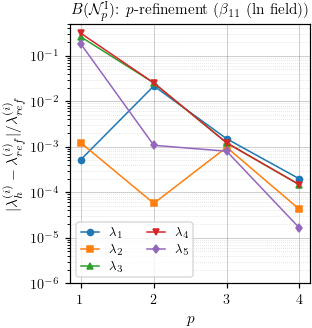

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


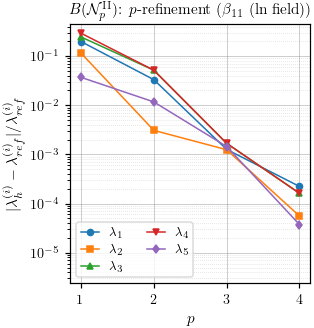

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


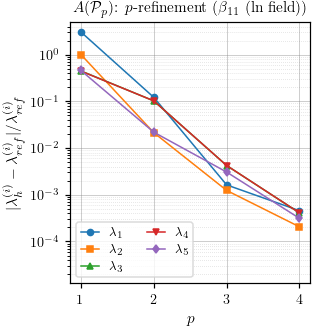


--- Processing p-refinement: $\beta_9$, $\alpha = 1.0$ ---


**$p$-refinement, **B(N1)**, $\beta_9$, $\alpha = 1.0$, $N = 6$, $R_m = 20$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,313,2.223e-02,2.223e-02,1.171e-01,5.771e-03,5.771e-03,1.25e+02
2,1057,2.054e-03,2.054e-03,4.575e-03,1.800e-03,1.800e-03,2.34e+02
3,2233,5.982e-05,5.982e-05,1.277e-04,9.897e-05,9.897e-05,3.96e+02
4,3841,5.325e-06,5.325e-06,8.937e-06,6.711e-06,6.711e-06,9.59e+02


**$p$-refinement, **B(N2)**, $\beta_9$, $\alpha = 1.0$, $N = 6$, $R_m = 20$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,769,2.182e-03,2.182e-03,4.451e-02,4.071e-03,4.071e-03,7.04e+01
2,1801,9.069e-04,9.069e-04,1.041e-03,1.189e-03,1.189e-03,3.46e+02
3,3265,1.683e-05,1.683e-05,7.613e-07,4.023e-05,4.023e-05,3.56e+02
4,5161,2.948e-06,2.948e-06,4.942e-06,3.944e-06,3.944e-06,8.05e+03


**$p$-refinement, **A(P)**, $\beta_9$, $\alpha = 1.0$, $N = 6$, $R_m = 20$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,86,7.020e-03,7.020e-03,1.501e-02,1.002e-02,1.002e-02,6.47e+01
2,314,7.144e-04,7.144e-04,2.411e-03,8.294e-04,8.294e-04,7.53e+02
3,686,8.679e-05,8.679e-05,1.868e-04,4.690e-05,4.690e-05,1.58e+03
4,1202,3.777e-06,3.777e-06,5.695e-06,4.147e-06,4.147e-06,3.64e+03


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


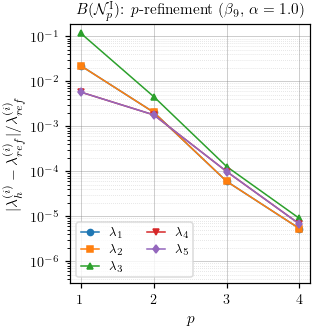

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


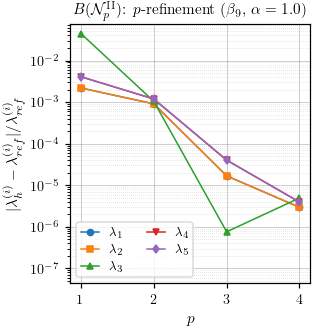

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


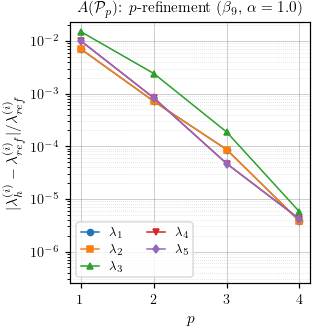


--- Processing p-refinement: $\beta_9$, $\alpha = 1.25$ ---


**$p$-refinement, **B(N1)**, $\beta_9$, $\alpha = 1.25$, $N = 6$, $R_m = 20$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,313,2.265e-02,2.265e-02,1.161e-01,8.061e-03,8.061e-03,1.02e+02
2,1057,1.992e-03,1.992e-03,3.850e-03,1.808e-03,1.808e-03,2.15e+02
3,2233,4.343e-05,4.343e-05,7.480e-05,1.039e-04,1.039e-04,2.51e+02
4,3841,3.718e-06,3.718e-06,6.302e-06,5.266e-06,5.266e-06,4.77e+02


**$p$-refinement, **B(N2)**, $\beta_9$, $\alpha = 1.25$, $N = 6$, $R_m = 20$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,769,3.782e-03,3.782e-03,4.223e-02,3.864e-03,3.864e-03,5.24e+01
2,1801,9.385e-04,9.385e-04,8.382e-04,1.257e-03,1.257e-03,2.49e+02
3,3265,1.126e-05,1.126e-05,9.366e-06,4.594e-05,4.594e-05,2.93e+02
4,5161,1.975e-06,1.975e-06,3.326e-06,3.024e-06,3.024e-06,4.36e+02


**$p$-refinement, **A(P)**, $\beta_9$, $\alpha = 1.25$, $N = 6$, $R_m = 20$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,86,7.874e-03,7.874e-03,2.074e-02,1.511e-02,1.511e-02,6.36e+01
2,314,6.877e-04,6.877e-04,2.179e-03,1.075e-03,1.075e-03,6.11e+02
3,686,7.922e-05,7.922e-05,1.265e-04,2.705e-05,2.705e-05,1.34e+03
4,1202,3.274e-06,3.274e-06,4.675e-06,3.768e-06,3.768e-06,3.02e+03


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


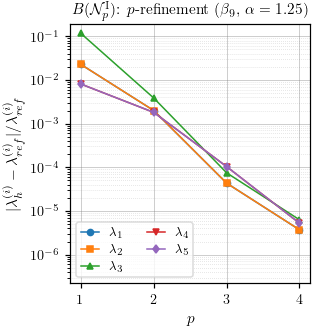

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


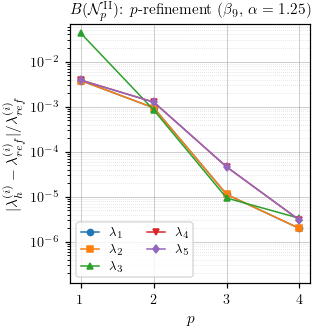

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


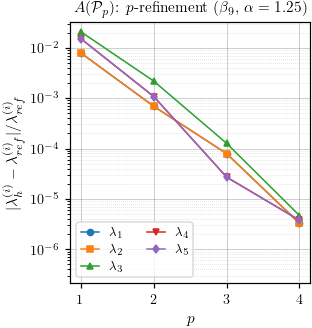


--- Processing p-refinement: $\beta_9$, $\alpha = 1.5$ ---


**$p$-refinement, **B(N1)**, $\beta_9$, $\alpha = 1.5$, $N = 6$, $R_m = 20$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,313,2.089e-02,2.089e-02,1.195e-01,1.222e-02,1.222e-02,8.76e+01
2,1057,1.692e-03,1.692e-03,3.198e-03,1.730e-03,1.730e-03,2.82e+02
3,2233,5.341e-05,5.341e-05,3.772e-05,1.093e-04,1.093e-04,3.60e+02
4,3841,5.365e-06,5.365e-06,4.037e-06,3.879e-06,3.879e-06,8.63e+02


**$p$-refinement, **B(N2)**, $\beta_9$, $\alpha = 1.5$, $N = 6$, $R_m = 20$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,769,5.026e-03,5.026e-03,4.062e-02,4.220e-03,4.220e-03,6.56e+01
2,1801,7.460e-04,7.460e-04,6.231e-04,1.301e-03,1.301e-03,2.39e+03
3,3265,1.606e-05,1.606e-05,1.499e-05,5.069e-05,5.069e-05,3.54e+02
4,5161,3.829e-06,3.829e-06,2.054e-06,2.174e-06,2.174e-06,3.71e+02


**$p$-refinement, **A(P)**, $\beta_9$, $\alpha = 1.5$, $N = 6$, $R_m = 20$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,86,7.904e-03,7.904e-03,2.597e-02,2.159e-02,2.159e-02,6.53e+01
2,314,4.292e-04,4.292e-04,1.959e-03,1.406e-03,1.406e-03,5.28e+02
3,686,1.049e-04,1.049e-04,7.999e-05,1.749e-05,1.749e-05,1.21e+03
4,1202,6.916e-06,6.916e-06,3.538e-06,3.674e-06,3.674e-06,2.68e+03


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


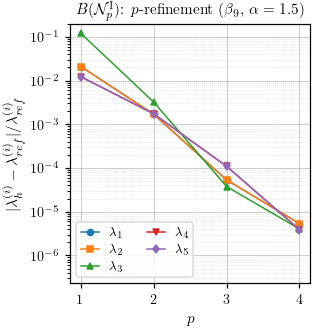

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


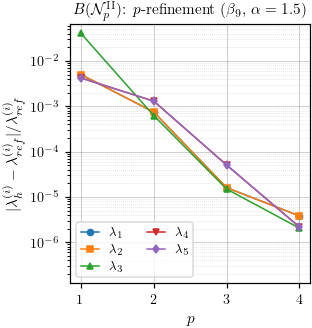

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


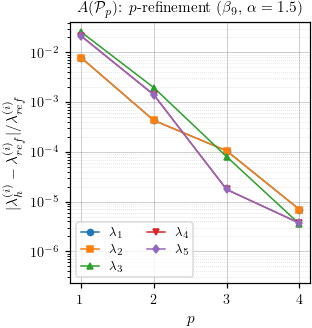


--- Processing p-refinement: $\beta_9$, $\alpha = 1.75$ ---


**$p$-refinement, **B(N1)**, $\beta_9$, $\alpha = 1.75$, $N = 6$, $R_m = 20$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,313,1.775e-02,1.775e-02,1.275e-01,1.735e-02,1.735e-02,6.41e+01
2,1057,1.221e-03,1.221e-03,2.616e-03,1.628e-03,1.628e-03,2.49e+02
3,2233,1.004e-04,1.004e-04,1.483e-05,1.186e-04,1.186e-04,3.76e+02
4,3841,1.341e-05,1.341e-05,1.614e-06,3.515e-06,3.515e-06,8.05e+02


**$p$-refinement, **B(N2)**, $\beta_9$, $\alpha = 1.75$, $N = 6$, $R_m = 20$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,769,5.481e-03,5.481e-03,4.080e-02,6.027e-03,6.027e-03,7.15e+01
2,1801,4.589e-04,4.589e-04,4.161e-04,1.328e-03,1.328e-03,3.62e+02
3,3265,6.102e-05,6.102e-05,1.540e-05,5.543e-05,5.543e-05,4.09e+02
4,5161,9.035e-06,9.035e-06,1.017e-06,2.033e-06,2.033e-06,4.16e+02


**$p$-refinement, **A(P)**, $\beta_9$, $\alpha = 1.75$, $N = 6$, $R_m = 20$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,86,1.175e-02,1.175e-02,3.068e-02,2.829e-02,2.829e-02,7.59e+01
2,314,2.059e-04,2.059e-04,1.754e-03,1.771e-03,1.771e-03,4.82e+02
3,686,1.073e-04,1.073e-04,4.504e-05,2.202e-05,2.202e-05,1.15e+03
4,1202,1.311e-05,1.311e-05,2.490e-06,5.107e-06,5.107e-06,2.52e+03


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


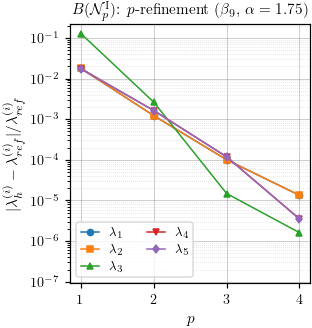

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


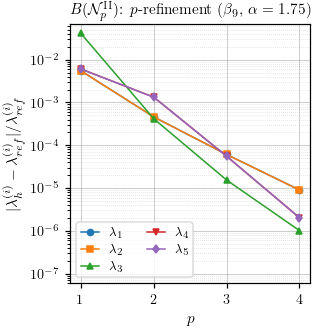

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


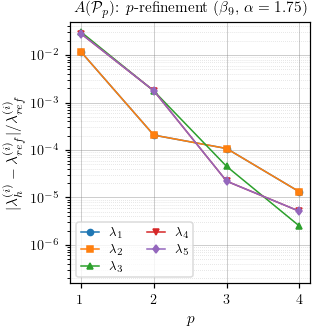

In [53]:
P_LEVELS = (1, 2, 3, 4)
N_PREF = 6

# 1. Update p_study with auto-reference generation and the SLEPc fail-safe
def p_study(form, field_key, levels=P_LEVELS, N=N_PREF, Rm=1.0, alpha=None, tau=None):
    """Errors of the first five eigenvalues as the degree rises on a fixed mesh."""
    dict_val = "ln" if field_key == "b11" else alpha
    ref_key = (field_key, dict_val)
    
    if ref_key not in REFERENCE_LP:
        print(f"  [!] Reference for {ref_key} missing. Generating high-order baseline now...")
        mesh_ref = crisscross_mesh(64)
        beta_ref = FIELDS[field_key](mesh_ref) if alpha is None else FIELDS[field_key](mesh_ref, alpha=alpha)
        stack = []
        for f in FORMS:
            res = solve_form(f, mesh_ref, 3, Rm=Rm, tau=tau, beta=beta_ref, nev=50, n_eigs=5, field=field_key, alpha=alpha)
            stack.append(res.values[:5])
        REFERENCE_LP[ref_key] = np.array(stack).mean(axis=0)
        
    ref = REFERENCE_LP[ref_key]
        
    mesh = crisscross_mesh(N)
    beta = (FIELDS[field_key](mesh) if alpha is None else FIELDS[field_key](mesh, alpha=alpha))
            
    rows = []
    for r in levels:
        try:
            # Explicitly pass tau
            res = solve_form(form, mesh, r, beta=beta, Rm=Rm, tau=tau, nev=25, field=field_key, alpha=alpha)
            got = assign(ref, res.values)
            kappa_val = res.kappa.get("MUMPS COND1", np.nan)
            dof_val = res.size
        except Exception as e:
            print(f"      [!] SLEPc solver breakdown at p={r}. Logging NaNs to table.")
            got = np.full(5, np.nan)
            kappa_val = np.nan
            dof_val = np.nan
            
        rows.append(dict(r=r, dof=dof_val,
                         **{EIG_COLS[j]: abs(got[j] - ref[j]) / abs(ref[j]) for j in range(5)},
                         **{r"$\kappa_1$": kappa_val}))
                         
    return pd.DataFrame(rows).set_index("r")


# 2. Master Loop: Route parameters, display tables, and generate plots for p-refinement
TEST_CASES = ["ln"] + list(ALPHAS)

for val in TEST_CASES:
    if val == "ln":
        field_key = "b11"
        alpha_arg = None
        field_tex = r"$\beta_{11}$ ($\ln$ field)"
        plot_name_base = "b11"
    else:
        field_key = "b9"
        alpha_arg = val
        field_tex = rf"{BETA_TEX['b9']}, $\alpha = {val}$"
        plot_name_base = f"b9_a{str(val).replace('.', 'p')}"

    print(f"\n--- Processing p-refinement: {field_tex} ---")
    
    # Compute the convergence data up to p=4
    p_tables_lp = {f: p_study(f, field_key, levels=P_LEVELS, N=N_PREF, alpha=alpha_arg, 
                              Rm=20.0, tau=0.9) for f in FORMS}

    # Display the numerical tables
    for f in FORMS:
        display(show(p_tables_lp[f], default="{:.3e}",
                     rules=[("dof", "{:.0f}"), (r"$\kappa_1$", "{:.2e}")],
                     caption=rf"$p$-refinement, **{f}**, {field_tex}, $N = {N_PREF}$, $R_m = 20$"))

    # Generate and save the convergence plots
    for f in PANEL_FORMS:
        df = p_tables_lp[f].dropna() # Drop any breakdown NaNs so matplotlib doesn't crash
        p_vals = np.asarray(df.index, float)
        e_vals = [df[c].to_numpy() for c in EIG_COLS]
        
        conv_panel(
            p_vals, [(rf"$\lambda_{{{j+1}}}$", e_vals[j]) for j in range(5)],
            xlabel=r"$p$", ylabel=REL_ERR,
            title=rf"{TEXP[f]}: $p$-refinement ({field_tex})",
            logx=False, xticks=P_LEVELS, numticks=40, legend_loc="lower left",
            name=f"breg1_p_{plot_name_base}_{TAG[f]}"
        )

## Notes

**Parameter re-runs** (same cell, one literal changed; stored outputs dropped).
(a) Table A.5: `beta_regularity_1form.ipynb[11]` (saved at `Rm=10.0`, Table A.7) with `Rm=5.0`.
(b) Table A.6: `[8]` with `RM_ref = 1` set to `RM_ref = 5`, then `[9]` verbatim (its caption string still reads $R_m = 1$).
(c) Figure 4.9: `[47]` and `[48]` with the key `"B(N^I)"` set to `"B(N2)"`. The saved cell raises a LaTeX
`RuntimeError` at its `ps_grid` call (`^` outside maths in the raw title), which would stop a top-to-bottom run.
The numbers are unchanged: `space()` only recognises `"A(P)"` and `"B(N1)"` and already built the N2curl pencil
for the saved key (diagnostics `N = 361473`, the $B(\mathcal{N}^{\mathrm{II}}_3)$ size), so the row labelled
$B(\mathcal{N}^{\mathrm{I}}_3)$ in the thesis is in fact the $B(\mathcal{N}^{\mathrm{II}}_3)$ discretisation.

**Caveats** (reported, not fixed).
- Figure 4.7: the caption says 300 eigenvalues; `run_ps` is called without `nev`, whose default (200) was bound
  before `PS_NEV = 300` was set, and the saved diagnostics ($m$ = 205–242) confirm 200.
- Figure 4.9: the caption says 20 eigenvalues and $\tau = 0.9$; the run uses the `run_ps` defaults, 200 eigenvalues and
  $\tau = 0.9/R_m = 0.045$.
- Tables A.6, A.8, A.9: the captions say $\tau = 0.9$; `solve_form` is called without `tau`, so the shift is $0.9/R_m$
  (0.18 at $R_m = 5$, 0.09 at $R_m = 10$). The stored tables at those shifts are the thesis numbers.
- Table A.10: the thesis prints $\kappa = 5.11\times10^{6}$ for $A(\mathcal{P}_3)$ under $\beta_{11}$; the output is
  $5.11\times10^{5}$ (transcription).
- Caption strings inside some cells are stale: `[44]` says $R_m = 100$ (run: 20); the appendix copies `[11]`, `[14]`
  say $R_m = 1$ (run: 10). Table A.9 in the thesis prints `--` for $\kappa$; the stored table has the MUMPS values.
- The Figure 4.6 block is taken from the appendix copy of the notebook (`[18]`–`[30]`), which is the same code as the
  primary `[13]`–`[25]` but runs top to bottom (the primary copy relied on kernel state: `h_tables` rebound per field
  and refilled by a cell that reads an undefined `unstructured_square_mesh` through `structure=False`). `h_study`
  still names `unstructured_square_mesh`, a dead branch (`structure=True` everywhere).
- `[8]` carries a stale `NameError` traceback from an earlier version of the cell; `[9]`'s stored table is the
  successful $R_m = 1$ run (Table A.11). `[45]`'s stored output regenerated two references itself; run top to bottom,
  `[44]` supplies all of them.

**Dropped.** `beta_regularity_1form.ipynb[13]`–`[25]` (replaced by the appendix copy, above); `[28]` (empty); `[30]`,
`[31]`, `[33]` (drafts of Figure 4.7 superseded by `[32]`); `[34]`–`[35]` ($\beta_8$ pseudospectra, not in the thesis);
`[37]`–`[41]` (resolvent-disagreement sweep, not in the thesis); `[49]` (never executed); the source markdown.
